# Полный каузальный пайплайн на синтетических данных
## Сравнение MSE каузальных моделей vs ML при наличии вмешательства (intervention)

**Источник данных:** `synthetic_data/` — CSV из `synthetic_causal_data.ipynb`

**Цель:** применить логику 5 скриптов (`step1`–`step5`) к трём сценариям  
и построить таблицу восстановления истинного каузального эффекта θ*.

| Сценарий | Структура | θ* | Вмешательство |
|----------|-----------|-----|---------------|
| 1 | Линейный VAR(1): C→X, C→Y, X→Y | **0.8** | X[t₀] += Δ ≈ +2σ |
| 2 | SETAR (пороговый): β=0.5/1.5 | **0.5 / 1.5** | нет |
| 3 | Латентный конфаундер U (ненабл.) | **0.7** | нет |

## 0. Импорты и конфигурация

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from typing import List, Dict, Tuple, Optional

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

from sklearn.linear_model import Ridge, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

SEED        = 42
TRAIN_RATIO = 0.75      # 75% обучение / 25% тест
T0          = 300       # момент вмешательства (Сценарий 1)
DATA_DIR    = Path('synthetic_data')

# Истинные каузальные эффекты
TRUE_EFFECTS = {
    'scenario1': {'theta_XY': 0.8,  'theta_CY': -0.3},
    'scenario2': {'beta_low': 0.5,  'beta_high': 1.5},
    'scenario3': {'theta_XY': 0.7},
}

np.random.seed(SEED)
plt.rcParams.update({'figure.dpi':120, 'font.size':11, 'axes.titlesize':12})
print('Готово. DATA_DIR:', DATA_DIR.resolve())
print('Файлов:', len(list(DATA_DIR.glob('*.csv'))))

Готово. DATA_DIR: D:\Образование\Магистратура\Диплом\ITMO_VKR\ITMO_VKR\syntetic data\synthetic_data
Файлов: 51


---
## STEP 1 — DAG Definition

Адаптируем структуру `AssetDAG` из `step1_dag_definitions.py` под синтетические сценарии.

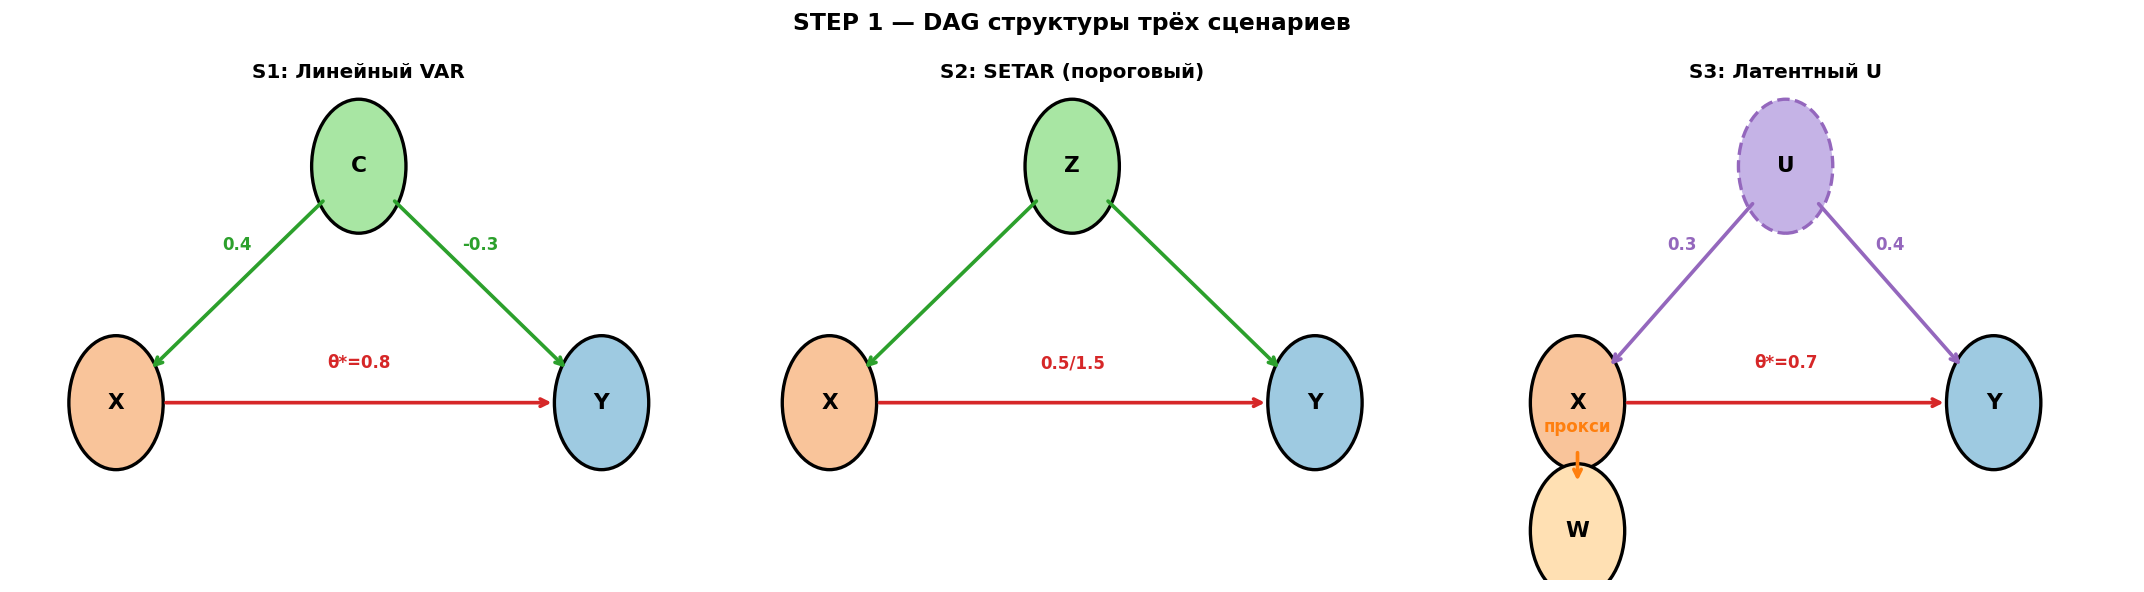

DAG определены для всех трёх сценариев.


In [2]:
from dataclasses import dataclass, field

@dataclass
class SyntheticDAG:
    """Аналог AssetDAG из step1_dag_definitions.py для синтетических данных."""
    name:        str
    target:      str
    causes:      List[str]
    confounders: List[str]
    mediators:   List[str]
    instruments: List[str]
    true_effect: Dict[str, float]
    notes:       str = ''

# ── Сценарий 1: C→X, C→Y, X→Y ───────────────────────────────────────────────
DAG_S1 = SyntheticDAG(
    name        = 'Scenario1_LinearVAR',
    target      = 'Y',
    causes      = ['X'],
    confounders = ['C'],          # C — backdoor конфаундер
    mediators   = [],
    instruments = [],
    true_effect = {'X_lag1': 0.8, 'C_lag1': -0.3, 'Y_lag1': 0.2},
    notes       = 'Backdoor: X←C→Y. Без C оценка θ(X→Y) смещена.'
)

# ── Сценарий 2: SETAR — пороговый эффект ─────────────────────────────────────
DAG_S2 = SyntheticDAG(
    name        = 'Scenario2_SETAR',
    target      = 'Y',
    causes      = ['X'],
    confounders = ['Z'],          # Z — наблюдаемый конфаундер
    mediators   = [],
    instruments = [],
    true_effect = {'beta_low': 0.5, 'beta_high': 1.5},
    notes       = 'Нелинейный эффект: β=0.5 при |X|<1, β=1.5 при |X|≥1'
)

# ── Сценарий 3: латентный конфаундер U ───────────────────────────────────────
DAG_S3 = SyntheticDAG(
    name        = 'Scenario3_LatentConfounder',
    target      = 'Y',
    causes      = ['X'],
    confounders = [],             # U ненаблюдаем! W — прокси
    mediators   = [],
    instruments = ['W'],         # W — прокси для U
    true_effect = {'X_lag1': 0.7},
    notes       = 'U — латентный конфаундер. W=rolling_vol(X) — прокси. Смещение при игнорировании U.'
)

ALL_DAGS = {'scenario1': DAG_S1, 'scenario2': DAG_S2, 'scenario3': DAG_S3}

# ── Визуализация DAG ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('STEP 1 — DAG структуры трёх сценариев', fontsize=14, fontweight='bold')

dags_viz = [
    ('S1: Линейный VAR',
     {'C':(5,4.2,'#a8e6a3'),'X':(1.5,1.8,'#f9c49a'),'Y':(8.5,1.8,'#9ecae1')},
     [('C','X','0.4','#2ca02c'),('C','Y','-0.3','#2ca02c'),('X','Y','θ*=0.8','#d62728')]),
    ('S2: SETAR (пороговый)',
     {'Z':(5,4.2,'#a8e6a3'),'X':(1.5,1.8,'#f9c49a'),'Y':(8.5,1.8,'#9ecae1')},
     [('Z','X','','#2ca02c'),('Z','Y','','#2ca02c'),('X','Y','0.5/1.5','#d62728')]),
    ('S3: Латентный U',
     {'U':(5,4.2,'#c5b3e6'),'X':(2,1.8,'#f9c49a'),'Y':(8,1.8,'#9ecae1'),'W':(2,0.5,'#ffe0b3')},
     [('U','X','0.3','#9467bd'),('U','Y','0.4','#9467bd'),
      ('X','Y','θ*=0.7','#d62728'),('X','W','прокси','#ff7f0e')]),
]
for ax,(title,nodes,edges) in zip(axes,dags_viz):
    ax.set_xlim(0,10); ax.set_ylim(0,5); ax.axis('off')
    ax.set_title(title, fontweight='bold')
    for name,(x,y,col) in nodes.items():
        style = '--' if name=='U' else '-'
        ec = '#9467bd' if name=='U' else 'black'
        ax.add_patch(plt.Circle((x,y),0.68,color=col,ec=ec,lw=2,ls=style,zorder=3))
        ax.text(x,y,name,ha='center',va='center',fontsize=13,fontweight='bold',zorder=4)
    for s,d,lbl,col in edges:
        sx,sy,_=nodes[s]; dx,dy,_=nodes[d]
        ax.annotate('',xy=(dx,dy),xytext=(sx,sy),
            arrowprops=dict(arrowstyle='->',lw=2.2,color=col,shrinkA=30,shrinkB=30))
        if lbl:
            ax.text((sx+dx)/2,(sy+dy)/2+0.35,lbl,ha='center',fontsize=10,
                    color=col,fontweight='bold')

plt.tight_layout(); plt.show()
print('DAG определены для всех трёх сценариев.')

---
## STEP 2 — Загрузка данных и отбор переменных

**Логика из `step2_variable_selection.py`:**
- Метод A: LassoCV (эвристический)
- Метод B: Backdoor criterion (экспертный DAG)
- ADF тест стационарности

In [3]:
# ── Загрузка всех реализаций ─────────────────────────────────────────────────
def load_scenario(scenario: str, n_real: int = 10, suffix: str = '') -> List[pd.DataFrame]:
    """Загружает N реализаций сценария из synthetic_data/"""
    frames = []
    for i in range(1, n_real+1):
        fname = f'{scenario}_realization_{i:02d}{suffix}.csv'
        p = DATA_DIR / fname
        if p.exists():
            df = pd.read_csv(p, index_col=0)
            df.index = pd.RangeIndex(len(df))
            frames.append(df)
    return frames

# ── ADF тест ─────────────────────────────────────────────────────────────────
def adf_pval(series):
    try: return adfuller(series.dropna(), autolag='AIC')[1]
    except: return 1.0

def check_stationarity(df: pd.DataFrame, cols: List[str]) -> Dict[str, bool]:
    """Возвращает словарь {col: is_stationary}"""
    result = {}
    for col in cols:
        if col in df.columns:
            p = adf_pval(df[col])
            result[col] = p < 0.05
    return result

# ── Приведение к стационарности (только если нужно) ─────────────────────────
def make_stationary(df: pd.DataFrame, target: str, force_diff: bool = False) -> pd.DataFrame:
    """Приводит к стационарности только нестационарные ряды."""
    result = {}
    for col in df.columns:
        s = df[col].dropna()
        if len(s) < 20:
            continue
        if force_diff or not check_stationarity(df, [col])[col]:
            # Используем diff() только для явно нестационарных
            result[col] = df[col].diff()
        else:
            result[col] = df[col]
    return pd.DataFrame(result).dropna()

# ── Метод B: Экспертный backdoor ─────────────────────────────────────────────
def select_expert_backdoor(dag: SyntheticDAG) -> List[str]:
    return [z for z in dag.confounders if z not in dag.mediators]

# ── Загружаем и анализируем ──────────────────────────────────────────────────
s1_frames = load_scenario('scenario1', 10)
s2_frames = load_scenario('scenario2', 10)
s3_frames = load_scenario('scenario3', 10, suffix='_observed')

# Основной датафрейм — первая реализация каждого сценария
df1 = s1_frames[0].copy()
df2 = s2_frames[0].copy()
df3 = s3_frames[0].copy()

print(f'Загружено реализаций: S1={len(s1_frames)}, S2={len(s2_frames)}, S3={len(s3_frames)}')
print()

# ADF тесты
for name, df, cols in [('S1', df1, ['Y','X','C']),
                        ('S2', df2, ['Y','X','Z']),
                        ('S3', df3, ['Y','X','W'])]:
    print(f'{name} — ADF тест:')
    for col in cols:
        if col in df.columns:
            p = adf_pval(df[col])
            p = adf_pval(df[col])
            status = "стационарен" if p < 0.05 else "нестационарен → возможен diff"
            print(f'  {col}: p={p:.4f} — {status}')
    print()

Загружено реализаций: S1=10, S2=10, S3=10

S1 — ADF тест:
  Y: p=0.0000 — стационарен
  X: p=0.0000 — стационарен
  C: p=0.0000 — стационарен

S2 — ADF тест:
  Y: p=0.0000 — стационарен
  X: p=0.0000 — стационарен
  Z: p=0.0000 — стационарен

S3 — ADF тест:
  Y: p=0.0000 — стационарен
  X: p=0.0000 — стационарен
  W: p=0.0000 — стационарен



In [4]:
# ── Отбор переменных по всем методам ────────────────────────────────────────
var_selection = {}

for scenario, dag, df in [('scenario1', DAG_S1, df1),
                            ('scenario2', DAG_S2, df2),
                            ('scenario3', DAG_S3, df3)]:
    df_stat = df.copy()
    all_cands = [c for c in df_stat.columns if c != dag.target]

    expert    = select_expert_backdoor(dag)
    # Для S3: expert пустой (U не наблюдаем), добавляем прокси W
    if scenario == 'scenario3':
        expert_with_proxy = expert + [c for c in dag.instruments if c in df_stat.columns]
    else:
        expert_with_proxy = expert

    var_selection[scenario] = {
        'dag':       dag,
        'df':        df,
        'df_stat':   df_stat,
        'expert':    expert_with_proxy,
        'causes':    dag.causes,
    }
    print(f'{scenario}:')
    print(f'  Expert (backdoor)  : {expert_with_proxy}')
    print()

scenario1:
  Expert (backdoor)  : ['C']

scenario2:
  Expert (backdoor)  : ['Z']

scenario3:
  Expert (backdoor)  : ['W']



---
## STEP 3 — Каузальные модели

**Методы из `step3_causal_models.py`:**
1. **SCM / OLS+backdoor** — правильная спецификация с контролем конфаундеров
2. **DML** — Double Machine Learning, partialling-out с cross-fitting
3. **VAR + Granger** — VAR(p) с отбором значимых переменных
4. **IV-2SLS** — инструментальные переменные (Сценарий 3: W как инструмент)

In [5]:
# ── Общие утилиты ─────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, label=''):
    mask = ~(np.isnan(y_true)|np.isnan(y_pred))
    yt,yp = y_true[mask], y_pred[mask]
    if len(yt)==0: return {'RMSE':np.nan,'MAE':np.nan,'MAPE':np.nan,'R2':np.nan}
    rmse = np.sqrt(mean_squared_error(yt,yp))
    mae  = mean_absolute_error(yt,yp)
    mape = np.mean(np.abs((yt-yp)/(np.abs(yt)+1e-9)))*100
    r2   = r2_score(yt,yp)
    return {'RMSE':round(rmse,6),'MAE':round(mae,6),'MAPE':round(mape,4),'R2':round(r2,4)}

def make_lag_features(df, target, controls, n_lags=2):
    all_vars = [target] + [c for c in controls if c in df.columns]
    feat = {}
    for lag in range(1, n_lags+1):
        for v in all_vars:
            feat[f'{v}_lag{lag}'] = df[v].shift(lag)
    fd = pd.DataFrame(feat).dropna()
    y  = df[target].loc[fd.index]
    return fd, y

def ts_split(X, y, ratio=TRAIN_RATIO):
    n = len(X); cut = int(n*ratio)
    return X.iloc[:cut], X.iloc[cut:], y.iloc[:cut], y.iloc[cut:]

# ── МЕТОД 1: SCM / OLS + backdoor ────────────────────────────────────────────
def run_scm_ols(df, target, controls, causes):
    """OLS с полным backdoor adjustment set."""
    all_ctrl = list(dict.fromkeys(causes+controls))                 # Формирование набора контрольных переменных
    fd, y = make_lag_features(df, target, all_ctrl, n_lags=2)       # Создание лаговых признаков
    # Проверка достаточности данных
    if len(fd) < 60: 
        return {'method':'SCM_SKIP','metrics':{}}
    X_tr,X_te,y_tr,y_te = ts_split(fd,y)
    model = OLS(y_tr, add_constant(X_tr)).fit()
    y_pred = model.predict(add_constant(X_te))
    cause_col = f'{causes[0]}_lag1' if f'{causes[0]}_lag1' in fd.columns else None
    theta = float(model.params.get(cause_col, np.nan)) if cause_col else np.nan
    return {'method':'SCM_OLS',
            'metrics':compute_metrics(y_te.values,y_pred),
            'theta_hat':theta,
            'preds':y_pred,
            'y_true':y_te.values}

# ── МЕТОД 2: DML — partialling-out ───────────────────────────────────────────
def run_dml(df, target, controls, causes, n_folds=5):

    all_ctrl = list(dict.fromkeys(causes+controls))
    fd, y = make_lag_features(df, target, all_ctrl, n_lags=2)
    if len(fd) < 60: return {'method':'DML_SKIP','metrics':{}}
    X_tr,X_te,y_tr,y_te = ts_split(fd,y)

    # Разделение признаков на treatment и control
    feat_cols = list(fd.columns)
    d_cols = [f'{c}_lag1' for c in causes if f'{c}_lag1' in feat_cols]
    w_cols = [c for c in feat_cols if c not in d_cols]
    if not d_cols or not w_cols:
        return {'method':'DML_SKIP','metrics':{}}

    W_tr = X_tr[w_cols].values; D_tr = X_tr[d_cols].values
    W_te = X_te[w_cols].values; D_te = X_te[d_cols].values
    
    # Кросс-фитинг (cross-fitting) для устранения смещения
    n = len(y_tr); fsize = n//n_folds

    Y_res=np.zeros(n); D_res=np.zeros((n,D_tr.shape[1]))
    for k in range(n_folds):
        val=np.arange(k*fsize,min((k+1)*fsize,n))
        tr_k=np.concatenate([np.arange(0,k*fsize),np.arange(min((k+1)*fsize,n),n)])
        if len(tr_k)<10: continue
        my=GradientBoostingRegressor(n_estimators=80,max_depth=3,random_state=k)
        my.fit(W_tr[tr_k],y_tr.values[tr_k])
        Y_res[val]=y_tr.values[val]-my.predict(W_tr[val])
        for j in range(D_tr.shape[1]):
            md_=GradientBoostingRegressor(n_estimators=80,max_depth=3,random_state=j)
            md_.fit(W_tr[tr_k],D_tr[tr_k,j])
            D_res[val,j]=D_tr[val,j]-md_.predict(W_tr[val])

    # θ̂ = (D̃ᵀD̃)⁻¹ D̃ᵀỸ
    theta_dml = np.linalg.lstsq(D_res,Y_res,rcond=None)[0]
    se = np.sqrt(np.mean((Y_res-D_res@theta_dml)**2)/(D_res.shape[0]*D_res.shape[1]+1e-12))
    ci = (float(theta_dml[0])-1.96*se, float(theta_dml[0])+1.96*se)

    my_full=GradientBoostingRegressor(n_estimators=100,max_depth=3,random_state=0)
    my_full.fit(W_tr,y_tr.values)
    D_res_te=np.zeros_like(D_te)
    for j in range(D_tr.shape[1]):
        md_f=GradientBoostingRegressor(n_estimators=80,max_depth=3,random_state=j)
        md_f.fit(W_tr,D_tr[:,j])
        D_res_te[:,j]=D_te[:,j]-md_f.predict(W_te)
    y_pred=my_full.predict(W_te)+D_res_te@theta_dml

    return {'method':'DML','metrics':compute_metrics(y_te.values,y_pred),
            'theta_hat':float(theta_dml[0]),'ci':ci,'se':se,
            'preds':y_pred,'y_true':y_te.values}

# ── МЕТОД 3: VAR + Granger ────────────────────────────────────────────────────
def run_var_granger(df, target, controls, causes, max_lags=4):
    """VAR(p) с Granger-тестом отбора переменных."""
    candidates = list(dict.fromkeys(causes+controls))
    avail = [c for c in candidates if c in df.columns]
    sub = df[[target]+avail].dropna()
    if len(sub)<50: return {'method':'VAR_SKIP','metrics':{}}

    cut=int(len(sub)*TRAIN_RATIO); train=sub.iloc[:cut]; test=sub.iloc[cut:]

    sig=[]; pvals={}
    for col in avail:
        try:
            gr=grangercausalitytests(train[[target,col]],maxlag=min(max_lags,4),verbose=False)
            p=min(gr[l][0]['ssr_ftest'][1] for l in range(1,min(max_lags,4)+1))
            pvals[col]=round(p,4)
            if p<0.05: sig.append(col)
        except: pass
    if not sig: sig=sorted(pvals,key=pvals.get)[:3]

    try:
        best_lag=max(1,VAR(train[[target]+sig[:5]]).fit(maxlags=max_lags,ic='aic').k_ar)
    except: best_lag=2

    try:
        var_fit=VAR(train[[target]+sig[:5]]).fit(best_lag)
        x_pos=([target]+sig[:5]).index(causes[0]) if causes[0] in sig[:5] else None
        theta_var=float(var_fit.coefs[0,0,x_pos]) if x_pos else np.nan

        history=train[[target]+sig[:5]].values.copy(); preds=[]
        for i in range(len(test)):
            fc=var_fit.forecast(history[-best_lag:],steps=1)
            preds.append(fc[0,0])
            history=np.vstack([history,test[[target]+sig[:5]].iloc[i].values])

        preds=np.array(preds); y_true=test[target].values[:len(preds)]
        return {'method':f'VAR(lag={best_lag})','metrics':compute_metrics(y_true,preds),
                'theta_hat':theta_var,'granger_pvals':pvals,
                'preds':preds,'y_true':y_true}
    except Exception as e:
        return {'method':'VAR_FAILED','metrics':{},'error':str(e)}

# ── МЕТОД 4: IV-2SLS ──────────────────────────────────────────────────────────
def run_iv_2sls(df, target, controls, causes, instruments):
    """2SLS: instruments → X̂ (stage1), X̂ → Y (stage2).
    controls не должны содержать instruments — разделяются на уровне вызова.
    """
    from sklearn.linear_model import LinearRegression
    avail_inst = [c for c in instruments if c in df.columns]
    if not avail_inst:
        return {'method':'IV_SKIP_no_instruments','metrics':{}}

    # Строим лаги только из causes + controls (без instruments — они идут отдельно)
    all_vars = list(dict.fromkeys(causes + controls))
    fd_base, y = make_lag_features(df, target, all_vars, n_lags=1)

    # Добавляем лаги инструментов вручную (n_lags=1)
    for inst_col in avail_inst:
        if inst_col in df.columns:
            fd_base[f'{inst_col}_lag1'] = df[inst_col].shift(1).loc[fd_base.index]
    fd = fd_base.dropna()
    y  = y.loc[fd.index]

    if len(fd)<60: return {'method':'IV_SKIP','metrics':{}}
    X_tr,X_te,y_tr,y_te = ts_split(fd,y)
    feat_cols = list(fd.columns)

    endog = [f'{c}_lag1' for c in causes      if f'{c}_lag1' in feat_cols]
    inst  = [f'{c}_lag1' for c in avail_inst  if f'{c}_lag1' in feat_cols]
    exog  = [c for c in feat_cols if c not in endog + inst]

    if not endog: return {'method':'IV_SKIP_no_endog','metrics':{}}

    W_tr = X_tr[exog].values if exog else np.ones((len(X_tr),1))
    W_te = X_te[exog].values if exog else np.ones((len(X_te),1))
    T_tr = X_tr[endog].values; T_te = X_te[endog].values
    Z_tr = X_tr[inst].values  if inst else T_tr
    Z_te = X_te[inst].values  if inst else T_te

    # Stage 1: T̂ = f(Z, W)
    s1 = LinearRegression().fit(np.hstack([Z_tr,W_tr]), T_tr)
    T_hat_tr = s1.predict(np.hstack([Z_tr,W_tr]))
    T_hat_te = s1.predict(np.hstack([Z_te,W_te]))

    # Stage 2: Y = f(T̂, W)
    s2 = LinearRegression().fit(np.hstack([T_hat_tr,W_tr]), y_tr.values)
    y_pred = s2.predict(np.hstack([T_hat_te,W_te]))

    theta_iv = float(s2.coef_[0])
    return {'method':'IV_2SLS','metrics':compute_metrics(y_te.values,y_pred),
            'theta_hat':theta_iv,'preds':y_pred,'y_true':y_te.values}


In [6]:
# ── Запуск каузальных моделей на всех сценариях ──────────────────────────────
print('Запуск каузальных моделей...')
causal_results = {}

for scenario, info in var_selection.items():
    dag     = info['dag']
    df_stat = info['df_stat']
    expert  = info['expert']
    causes  = info['causes']
    instrs  = dag.instruments

    # Для IV-2SLS: убираем инструменты из controls, чтобы не дублировать
    ctrl_iv = [c for c in expert if c not in instrs]

    print(f'\n── {scenario} ──')

    r_scm = run_scm_ols(df_stat, dag.target, expert, causes)
    r_dml = run_dml(df_stat, dag.target, expert, causes)
    r_var = run_var_granger(df_stat, dag.target, expert, causes)
    r_iv  = run_iv_2sls(df_stat, dag.target, ctrl_iv, causes, instrs)

    res = {
        'SCM_OLS':     r_scm,
        'DML':         r_dml,
        'VAR_Granger': r_var,
        'IV_2SLS':     r_iv,
    }

    for m_name, r in res.items():
        theta = r.get('theta_hat', np.nan)
        rmse  = r.get('metrics',{}).get('RMSE', np.nan)
        theta_str = f'θ̂={theta:.4f}' if theta is not None and not np.isnan(theta) else 'θ̂=—'
        rmse_str  = f'RMSE={rmse:.4f}' if rmse is not None and not np.isnan(rmse) else 'RMSE=—'
        print(f'  {m_name:15s}: {theta_str}  {rmse_str}')

    causal_results[scenario] = res

print('\nКаузальные модели завершены.')


Запуск каузальных моделей...

── scenario1 ──
  SCM_OLS        : θ̂=0.8318  RMSE=1.0173
  DML            : θ̂=0.7597  RMSE=1.1253
  VAR_Granger    : θ̂=0.8208  RMSE=1.0153
  IV_2SLS        : θ̂=—  RMSE=—

── scenario2 ──
  SCM_OLS        : θ̂=1.4957  RMSE=1.0694
  DML            : θ̂=1.4788  RMSE=4.1089
  VAR_Granger    : θ̂=1.4958  RMSE=1.0637
  IV_2SLS        : θ̂=—  RMSE=—

── scenario3 ──
  SCM_OLS        : θ̂=0.7822  RMSE=1.0688
  DML            : θ̂=0.6671  RMSE=1.2028
  VAR_Granger    : θ̂=0.7695  RMSE=1.0641
  IV_2SLS        : θ̂=0.6619  RMSE=1.4175

Каузальные модели завершены.


---
## STEP 4 — Baseline ML Models

**Методы из `step4_baseline_models.py`:**
1. **ARIMA** — rolling direct forecast
2. **Random Forest** — все лаговые признаки
3. **LightGBM** — градиентный бустинг
4. **Ridge (наивный)** — без контроля конфаундеров (демонстрация смещения θ)

In [7]:
# ── BASELINE: Ridge наивный (БЕЗ конфаундера — демонстрация смещения) ─────
def run_ridge_naive(df, target, causes):
    fd,y=make_lag_features(df,target,causes,n_lags=2)
    if len(fd)<60: return {'method':'Ridge_naive','metrics':{}}
    X_tr,X_te,y_tr,y_te=ts_split(fd,y)
    m=Ridge(alpha=0.5).fit(X_tr,y_tr)
    preds=m.predict(X_te)
    # θ̂: коэф. при X_lag1
    cause_lag='X_lag1'
    theta=float(m.coef_[list(fd.columns).index(cause_lag)]) if cause_lag in fd.columns else np.nan
    return {'method':'Ridge_naive','metrics':compute_metrics(y_te.values,preds),
            'theta_hat':theta,'preds':preds,'y_true':y_te.values}

In [8]:
# ── Запуск baseline на всех сценариях ────────────────────────────────────────
print('Запуск baseline моделей...')
baseline_results = {}

for scenario, info in var_selection.items():
    dag     = info['dag']
    df_stat = info['df_stat']
    expert  = info['expert']
    #union   = info['union']
    causes  = info['causes']

    print(f'\n── {scenario} ──')
    res = {}
    res['ridge_naive']  = run_ridge_naive(df_stat, dag.target, causes)

    baseline_results[scenario] = res
    for m_name, r in res.items():
        theta = r.get('theta_hat', np.nan)
        rmse  = r.get('metrics',{}).get('RMSE', np.nan)
        theta_str = f'θ̂={theta:.4f}' if theta is not None and not np.isnan(theta) else 'θ̂=—'
        rmse_str  = f'RMSE={rmse:.4f}' if rmse is not None and not np.isnan(rmse) else 'RMSE=—'
        print(f'  {m_name:20s}: {theta_str}  {rmse_str}')

print('\nBaseline модели завершены.')

Запуск baseline моделей...

── scenario1 ──
  ridge_naive         : θ̂=0.7663  RMSE=1.1093

── scenario2 ──
  ridge_naive         : θ̂=1.4951  RMSE=1.2526

── scenario3 ──
  ridge_naive         : θ̂=0.7252  RMSE=1.0586

Baseline модели завершены.


---
## Monte Carlo: восстановление θ* по 10 реализациям

Оцениваем Bias, RMSE(θ), Coverage 95% CI (где доступно) — аналог таблицы X из ВКР.

In [9]:
# ── Monte Carlo по всем реализациям ──────────────────────────────────────────
mc_rows = []

for scenario_key, frames, dag_key in [
        ('scenario1',  s1_frames, 'scenario1'),
        ('scenario2',  s2_frames, 'scenario2'),
        ('scenario3',  s3_frames, 'scenario3')]:

    dag = ALL_DAGS[dag_key]
    true_theta = {'scenario1':0.8, 'scenario2':1.5, 'scenario3':0.7}[dag_key]

    for i, df_i in enumerate(frames):
        df_stat_i = df_i.copy()
        instrs_i  = dag.instruments

        expert_i = select_expert_backdoor(dag)
        if dag_key == 'scenario3':
            expert_i += [c for c in instrs_i if c in df_stat_i.columns]

        # Для IV: controls без инструментов
        ctrl_iv_i = [c for c in expert_i if c not in instrs_i]
        causes_i  = dag.causes

        r_scm   = run_scm_ols(df_stat_i, dag.target, expert_i, causes_i)
        r_dml   = run_dml(df_stat_i, dag.target, expert_i, causes_i)
        r_var   = run_var_granger(df_stat_i, dag.target, expert_i, causes_i)
        r_iv    = run_iv_2sls(df_stat_i, dag.target, ctrl_iv_i, causes_i, instrs_i)
        r_naive = run_ridge_naive(df_stat_i, dag.target, causes_i)

        dml_theta = r_dml.get('theta_hat', np.nan)
        dml_ci    = r_dml.get('ci', (np.nan, np.nan))
        dml_in_ci = int(dml_ci[0]<=true_theta<=dml_ci[1]) if not np.isnan(dml_ci[0]) else np.nan

        mc_rows.append({
            'scenario':    scenario_key,
            'realization': i+1,
            'true_theta':  true_theta,
            'theta_SCM':   r_scm.get('theta_hat', np.nan),
            'theta_DML':   dml_theta,
            'theta_VAR':   r_var.get('theta_hat', np.nan),
            'theta_IV':    r_iv.get('theta_hat', np.nan),   # ← добавлено
            'theta_naive': r_naive.get('theta_hat', np.nan),
            'dml_in_ci':   dml_in_ci,
            'RMSE_SCM':    r_scm.get('metrics',{}).get('RMSE', np.nan),
            'RMSE_DML':    r_dml.get('metrics',{}).get('RMSE', np.nan),
            'RMSE_VAR':    r_var.get('metrics',{}).get('RMSE', np.nan),
            'RMSE_IV':     r_iv.get('metrics',{}).get('RMSE', np.nan),   # ← добавлено
            'RMSE_naive':  r_naive.get('metrics',{}).get('RMSE', np.nan),
        })

mc_df = pd.DataFrame(mc_rows)
print(f'Monte Carlo: {len(mc_df)} строк ({len(s1_frames)+len(s2_frames)+len(s3_frames)} реализаций × 3 сценария)')
print(mc_df[['scenario','realization','true_theta','theta_SCM','theta_DML','theta_VAR','theta_IV','theta_naive']].to_string(index=False))


Monte Carlo: 30 строк (30 реализаций × 3 сценария)
 scenario  realization  true_theta  theta_SCM  theta_DML  theta_VAR  theta_IV  theta_naive
scenario1            1         0.8   0.831810   0.759694   0.820757       NaN     0.766283
scenario1            2         0.8   0.709885   0.666375   0.727115       NaN     0.648345
scenario1            3         0.8   0.736103   0.708959   0.770349       NaN     0.662451
scenario1            4         0.8   0.722981   0.698882   0.762182       NaN     0.682516
scenario1            5         0.8   0.807253   0.754076   0.807253       NaN     0.722642
scenario1            6         0.8   0.784445   0.702858   0.800110       NaN     0.742823
scenario1            7         0.8   0.820355   0.806670   0.814059       NaN     0.745842
scenario1            8         0.8   0.702042   0.654688   0.751560       NaN     0.669433
scenario1            9         0.8   0.858856   0.821096   0.827817       NaN     0.759099
scenario1           10         0.8   0.

---
## STEP 5 — Comparison Report

### 5.1 Таблица восстановления θ* (ключевая таблица ВКР)

In [10]:
# ── Таблица: Bias / RMSE(θ) / Coverage ───────────────────────────────────────
summary_rows = []
method_map = {
    'SCM_OLS':     ('theta_SCM',  'RMSE_SCM',  'Каузальный'),
    'DML':         ('theta_DML',  'RMSE_DML',  'Каузальный'),
    'VAR+Granger': ('theta_VAR',  'RMSE_VAR',  'Каузальный'),
    'IV_2SLS':     ('theta_IV',   'RMSE_IV',   'Каузальный'),
    'Ridge_naive': ('theta_naive','RMSE_naive','ML-базлайн'),
}

for scen in mc_df['scenario'].unique():
    sub = mc_df[mc_df['scenario']==scen]
    true_t = sub['true_theta'].iloc[0]
    for method, (col_t, col_r, mtype) in method_map.items():
        thetas = sub[col_t].dropna() if col_t in sub.columns else pd.Series([], dtype=float)
        if len(thetas)==0: continue
        bias   = round(float(thetas.mean()-true_t), 5)
        rmse_t = round(float(np.sqrt(((thetas-true_t)**2).mean())), 5)
        coverage = '—'
        if method=='DML':
            cov_vals = sub['dml_in_ci'].dropna()
            coverage = f'{cov_vals.mean()*100:.0f}%' if len(cov_vals)>0 else '—'
        rmse_pred = sub[col_r].mean() if col_r in sub.columns else np.nan
        summary_rows.append({
            'Сценарий':      scen,
            'Метод':         method,
            'Тип':           mtype,
            'θ*':            true_t,
            'θ̂ (mean)':     round(float(thetas.mean()),5),
            'Bias':          bias,
            '|Bias|':        round(abs(bias),5),
            'RMSE(θ̂)':     rmse_t,
            'Coverage 95%': coverage,
            'RMSE_прогноз': round(float(rmse_pred),5) if not np.isnan(rmse_pred) else np.nan,
        })

summary_theta = pd.DataFrame(summary_rows)
print('Таблица восстановления истинного θ* (10 реализаций):')
print(f'  Bias = θ̂_mean − θ*,  RMSE(θ̂) = среднеквадр. отклонение от θ*')
print()
summary_theta.set_index(['Сценарий','Метод'])


Таблица восстановления истинного θ* (10 реализаций):
  Bias = θ̂_mean − θ*,  RMSE(θ̂) = среднеквадр. отклонение от θ*



Тип   θ*  θ̂ (mean)     Bias   |Bias|  RMSE(θ̂)  \
Сценарий  Метод                                                                 
scenario1 SCM_OLS      Каузальный  0.8    0.77533 -0.02467  0.02467   0.05773   
          DML          Каузальный  0.8    0.73531 -0.06469  0.06469   0.08459   
          VAR+Granger  Каузальный  0.8    0.78436 -0.01564  0.01564   0.03582   
          Ridge_naive  ML-базлайн  0.8    0.70343 -0.09657  0.09657   0.10725   
scenario2 SCM_OLS      Каузальный  1.5    1.49666 -0.00334  0.00334   0.00462   
          DML          Каузальный  1.5    1.50097  0.00097  0.00097   0.03134   
          VAR+Granger  Каузальный  1.5    1.49698 -0.00302  0.00302   0.00422   
          Ridge_naive  ML-базлайн  1.5    1.49583 -0.00417  0.00417   0.00540   
scenario3 SCM_OLS      Каузальный  0.7    0.73438  0.03438  0.03438   0.05772   
          DML          Каузальный  0.7    0.70699  0.00699  0.00699   0.04671   
          VAR+Granger  Каузальный  0.7    0.72879  0.02879  0.02879   0.05089   
          IV_2SLS      Каузальный  0.7    0.64899 -0.05101  0.05101   0.05679   
          Ridge_naive  ML-базлайн  0.7    0.69836 -0.00164  0.00164   0.02472   

                      Coverage 95%  RMSE_прогноз  
Сценарий  Метод                                   
scenario1 SCM_OLS                —       0.99451  
          DML                  80%       1.09629  
          VAR+Granger            —       0.99329  
          Ridge_naive            —       1.05436  
scenario2 SCM_OLS                —       1.10928  
          DML                 100%       5.49180  
          VAR+Granger            —       1.20885  
          Ridge_naive            —       1.19741  
scenario3 SCM_OLS                —       1.03273  
          DML                  90%       1.12184  
          VAR+Granger            —       1.03651  
          IV_2SLS                —       1.37800  
          Ridge_naive            —       1.03186

In [12]:
#summary_theta.to_excel('syntetic_data_results.xlsx')

### 5.4 Восстановление θ*: scatter θ̂ по реализациям

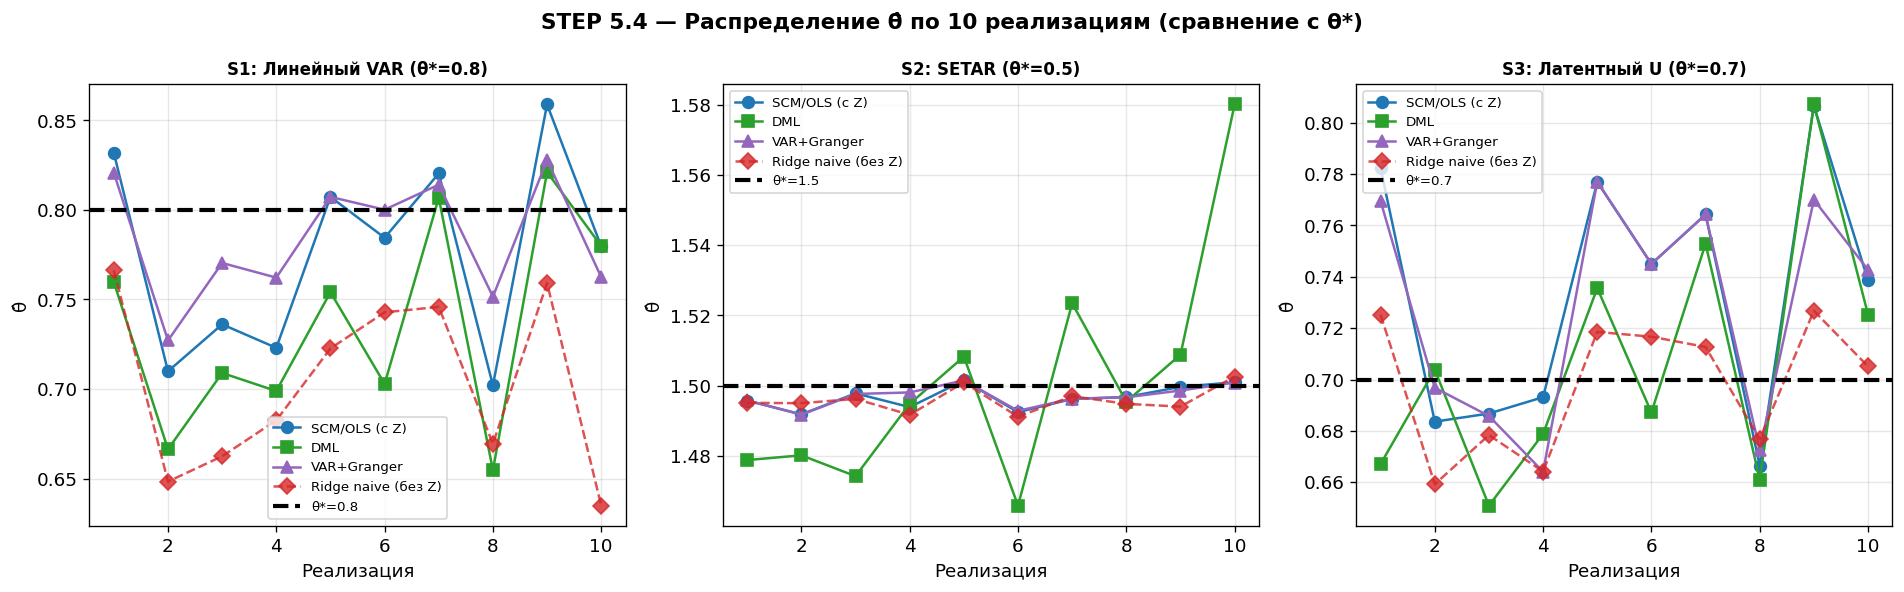

In [13]:
# ── Scatter θ̂ по реализациям (Expert vs Naive vs True) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('STEP 5.4 — Распределение θ̂ по 10 реализациям (сравнение с θ*)',
             fontsize=13, fontweight='bold')

scen_labels = {'scenario1':'S1: Линейный VAR (θ*=0.8)',
               'scenario2':'S2: SETAR (θ*=0.5)',
               'scenario3':'S3: Латентный U (θ*=0.7)'}

for ax, scen in zip(axes, ['scenario1','scenario2','scenario3']):
    sub = mc_df[mc_df['scenario']==scen]
    true_t = sub['true_theta'].iloc[0]
    x = sub['realization'].values

    ax.plot(x, sub['theta_SCM'],  'o-', color='#1f77b4', lw=1.5, ms=7, label='SCM/OLS (с Z)')
    ax.plot(x, sub['theta_DML'],  's-', color='#2ca02c', lw=1.5, ms=7, label='DML')
    ax.plot(x, sub['theta_VAR'],  '^-', color='#9467bd', lw=1.5, ms=7, label='VAR+Granger')
    ax.plot(x, sub['theta_naive'],'D--',color='#d62728', lw=1.5, ms=7, alpha=0.8, label='Ridge naive (без Z)')
    ax.axhline(true_t, color='black', lw=2.5, ls='--', label=f'θ*={true_t}')

    ax.set_title(scen_labels[scen], fontsize=10, fontweight='bold')
    ax.set_xlabel('Реализация'); ax.set_ylabel('θ̂')
    ax.legend(fontsize=8, loc='best'); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## STEP 6 — Валидация на синтетических данных

Для каждого из трёх сценариев реализуется полная процедура валидации:

1. **Вычисление истинного контрфактуала** — траектория $Y_t^{cf}$, которую принял бы $Y_t$ при отсутствии вмешательства (известна из структурных уравнений).
2. **Rolling Window** — оценка устойчивости каузальных методов к выбору обучающего периода.
3. **Метрики валидации**: CRE, RCEE, APEE, $\\rho_{\\text{effect}}$.

**Параметры скользящего окна** (из раздела 2.4.1.2):
- $T = 600$, $t_0 = 300$, $W_{train} = 250$, $W_{test} = 50$, $s = 25$


In [23]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.0 — Импорт методов из step3_causal_models.py и step4_baseline_models.py
#
# Модули импортируются напрямую. Если файлы лежат в другой папке —
# скорректируй путь в sys.path.insert ниже.
# ════════════════════════════════════════════════════════════════════════════

import sys
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler  # нужен для LSTM

# ── Путь к модулям (папка, где лежат step3/step4) ───────────────────────────
MODULE_DIR = Path('../')   # <-- при необходимости поменяй на реальный путь
if str(MODULE_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR.resolve()))

# ── Импорт функций ──────────────────────────────────────────────────────────
try:
    from step3_causal_models import (
        run_dml        as _run_dml_s3,
        run_scm_dowhy  as _run_scm_s3,
        prepare_ml_data as _prepare_ml,
        compute_metrics as _compute_metrics_s3,
        TRAIN_RATIO     as _TRAIN_RATIO_S3,
    )
    _S3_AVAILABLE = True
    print('step3_causal_models: OK')
except ImportError as e:
    _S3_AVAILABLE = False
    print(f'step3_causal_models недоступен: {e}')

try:
    from step4_baseline_models import (
        run_arima         as _run_arima_s4,
        run_random_forest as _run_rf_s4,
        run_lstm          as _run_lstm_s4,
        prepare_ml_data   as _prepare_ml_s4,
        compute_metrics   as _compute_metrics_s4,
        TRAIN_RATIO       as _TRAIN_RATIO_S4,
    )
    _S4_AVAILABLE = True
    print('step4_baseline_models: OK')
except ImportError as e:
    _S4_AVAILABLE = False
    print(f'step4_baseline_models недоступен: {e}')


step3_causal_models: OK
step4_baseline_models: OK


In [24]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.1a — Адаптеры функций из step3/step4 для синтетических данных
#
# Проблема совместимости:
#   • step3/step4 требуют DatetimeIndex (для predictions dict и strftime).
#   • Синтетические датафреймы используют RangeIndex.
#   • CausalImpact из step3 опирается на ALL_DAGS и requires внешний DAG объект.
#
# Адаптеры:
#   1. Добавляют фиктивный DatetimeIndex перед вызовом.
#   2. Извлекают массив predictions из dict-ответа (ключ 'predictions').
#   3. Возвращают унифицированный dict {method, preds, theta_hat, metrics}.
# ════════════════════════════════════════════════════════════════════════════

def _add_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет фиктивный дневной DatetimeIndex, совместимый с step3/step4."""
    df = df.copy()
    df.index = pd.date_range(start='2000-01-01', periods=len(df), freq='D')
    return df


def _extract_preds(result: dict, w_test: int) -> np.ndarray:
    """
    Извлекает массив прогнозов из dict-ответа step3/step4.
    Ключ 'predictions' — dict {date_str: value}  → берём values в порядке ключей.
    Обрезает или дополняет NaN до длины w_test.
    """
    preds_raw = result.get('predictions', None)
    if preds_raw is None:
        return np.full(w_test, np.nan)
    if isinstance(preds_raw, dict):
        arr = np.array(list(preds_raw.values()), dtype=float)
    else:
        arr = np.array(preds_raw, dtype=float).flatten()
    # Обрезаем до w_test, дополняем NaN если короче
    if len(arr) >= w_test:
        return arr[:w_test]
    return np.concatenate([arr, np.full(w_test - len(arr), np.nan)])


# ── ARIMA (step4) ─────────────────────────────────────────────────────────────
def run_arima_adapter(
    df_train: pd.DataFrame,
    target: str,
    w_test: int,
    horizon: int = 1,
) -> dict:
    """
    Обёртка над step4.run_arima.
    ARIMA обучается на df_train (весь переданный датафрейм),
    прогноз строится внутри функции для тестовой части (последние w_test точек).
    """
    if not _S4_AVAILABLE:
        return {'method': 'ARIMA_UNAVAILABLE', 'preds': np.full(w_test, np.nan), 'metrics': {}}
    try:
        df_dt = _add_datetime_index(df_train)
        res   = _run_arima_s4(df_dt, target, horizon=horizon)
        return {
            'method':    res.get('method', 'ARIMA'),
            'preds':     _extract_preds(res, w_test),
            'theta_hat': np.nan,
            'metrics':   res.get('metrics', {}),
        }
    except Exception as e:
        return {'method': f'ARIMA_ERR({e.__class__.__name__})',
                'preds': np.full(w_test, np.nan), 'metrics': {}}


# ── Random Forest (step4) ─────────────────────────────────────────────────────
def run_rf_adapter(
    df_train: pd.DataFrame,
    target: str,
    all_features: List[str],
    w_test: int,
    horizon: int = 1,
) -> dict:
    """Обёртка над step4.run_random_forest."""
    if not _S4_AVAILABLE:
        return {'method': 'RF_UNAVAILABLE', 'preds': np.full(w_test, np.nan), 'metrics': {}}
    try:
        df_dt = _add_datetime_index(df_train)
        avail = [c for c in all_features if c in df_dt.columns]
        res   = _run_rf_s4(df_dt, target, avail, horizon=horizon)
        return {
            'method':    res.get('method', 'RandomForest'),
            'preds':     _extract_preds(res, w_test),
            'theta_hat': np.nan,
            'metrics':   res.get('metrics', {}),
        }
    except Exception as e:
        return {'method': f'RF_ERR({e.__class__.__name__})',
                'preds': np.full(w_test, np.nan), 'metrics': {}}


# ── LSTM (step4) ──────────────────────────────────────────────────────────────
def run_lstm_adapter(
    df_train: pd.DataFrame,
    target: str,
    feature_cols: List[str],
    w_test: int,
    horizon: int = 1,
    epochs: int = 20,
    seq_len: int = 20,
) -> dict:
    """Обёртка над step4.run_lstm (PyTorch → Keras fallback)."""
    if not _S4_AVAILABLE:
        return {'method': 'LSTM_UNAVAILABLE', 'preds': np.full(w_test, np.nan), 'metrics': {}}
    try:
        df_dt = _add_datetime_index(df_train)
        avail = [c for c in feature_cols if c in df_dt.columns]
        res   = _run_lstm_s4(df_dt, target, avail,
                              seq_len=seq_len, horizon=horizon, epochs=epochs)
        return {
            'method':    res.get('method', 'LSTM'),
            'preds':     _extract_preds(res, w_test),
            'theta_hat': np.nan,
            'metrics':   res.get('metrics', {}),
        }
    except Exception as e:
        return {'method': f'LSTM_ERR({e.__class__.__name__})',
                'preds': np.full(w_test, np.nan), 'metrics': {}}


# ── CausalImpact / SCM-DoWhy (step3) ─────────────────────────────────────────
def run_causal_impact_adapter(
    df_train: pd.DataFrame,
    target: str,
    causes: List[str],
    controls: List[str],
    dag,
    w_test: int,
    horizon: int = 1,
) -> dict:
    """
    Обёртка над step3.run_scm_dowhy.
    В step3 эта функция называется run_scm_dowhy и реализует
    каузальный прогноз через backdoor adjustment (с fallback на Ridge).
    В контексте валидации используется как "CausalImpact-подобный" метод:
    прогнозирует контрфактуальную траекторию Y на post-intervention периоде.
    """
    if not _S3_AVAILABLE:
        return {'method': 'CausalImpact_UNAVAILABLE',
                'preds': np.full(w_test, np.nan), 'metrics': {}}
    try:
        df_dt = _add_datetime_index(df_train)
        avail_causes   = [c for c in causes   if c in df_dt.columns]
        avail_controls = [c for c in controls if c in df_dt.columns]
        res = _run_scm_s3(
            df_dt, target,
            causes=avail_causes,
            controls=avail_controls,
            dag=dag,
            horizon=horizon,
        )
        theta = np.nan
        return {
            'method':    res.get('method', 'CausalImpact_SCM'),
            'preds':     _extract_preds(res, w_test),
            'theta_hat': theta,
            'metrics':   res.get('metrics', {}),
        }
    except Exception as e:
        return {'method': f'CausalImpact_ERR({e.__class__.__name__})',
                'preds': np.full(w_test, np.nan), 'metrics': {}}


# ── DML (step3) ───────────────────────────────────────────────────────────────
def run_dml_s3_adapter(
    df_train: pd.DataFrame,
    target: str,
    causes: List[str],
    controls: List[str],
    w_test: int,
    horizon: int = 1,
) -> dict:
    """
    Обёртка над step3.run_dml (EconML LinearDML → ручной DML fallback).
    Использует n_lags=5 и cross-fitting согласно реализации в step3.
    """
    if not _S3_AVAILABLE:
        return {'method': 'DML_S3_UNAVAILABLE',
                'preds': np.full(w_test, np.nan), 'metrics': {}}
    try:
        df_dt = _add_datetime_index(df_train)
        avail_causes   = [c for c in causes   if c in df_dt.columns]
        avail_controls = [c for c in controls if c in df_dt.columns]
        res = _run_dml_s3(
            df_dt, target,
            causes=avail_causes,
            controls=avail_controls,
            horizon=horizon,
        )
        # Извлекаем theta: ключи 'theta' (dict) или 'causal_effects' (list)
        theta = np.nan
        if 'theta' in res:
            t_vals = list(res['theta'].values())
            theta = float(t_vals[0]) if t_vals else np.nan
        elif 'causal_effects' in res:
            ce = res['causal_effects']
            theta = float(ce[0]) if ce else np.nan
        return {
            'method':    res.get('method', 'DML_S3'),
            'preds':     _extract_preds(res, w_test),
            'theta_hat': theta,
            'metrics':   res.get('metrics', {}),
        }
    except Exception as e:
        return {'method': f'DML_S3_ERR({e.__class__.__name__})',
                'preds': np.full(w_test, np.nan), 'metrics': {}}


print('Адаптеры определены: ARIMA, RandomForest, LSTM, CausalImpact, DML (step3/step4)')


Адаптеры определены: ARIMA, RandomForest, LSTM, CausalImpact, DML (step3/step4)


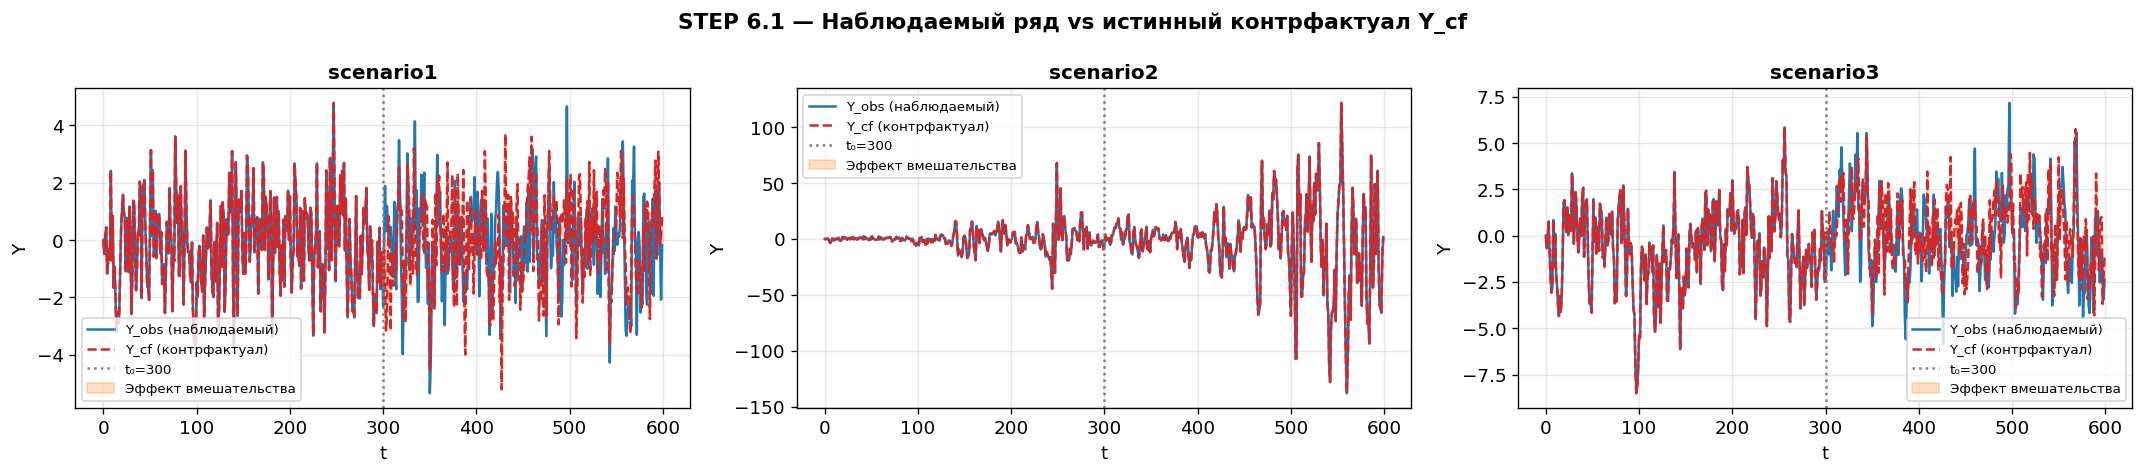

Истинные контрфактуалы вычислены.


In [25]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.1 — Вычисление истинного контрфактуала из структурных уравнений
# ════════════════════════════════════════════════════════════════════════════

# Параметры вмешательства (Сценарий 1: импульс +2σ в t0=300)
T_TOTAL     = 600
T0          = 300       # момент вмешательства
W_TRAIN     = 250       # длина обучающего окна
W_TEST      = 50        # длина тестового окна
STEP_SIZE   = 25        # шаг сдвига окна

# ── Генерация истинного контрфактуала для каждого сценария ──────────────────
def compute_true_counterfactual(
    df: pd.DataFrame,
    scenario: str,
    dag: 'SyntheticDAG',
    t0: int = T0,
    seed: int = SEED
) -> pd.Series:
    """
    Воссоздаёт траекторию Y_t^{cf} — значение Y при отсутствии вмешательства,
    используя те же структурные уравнения и те же шумы, что при генерации данных.

    Логика: восстанавливаем шум из уравнения Y на pre-intervention периоде,
    затем распространяем модель вперёд без вмешательства на X.
    """
    np.random.seed(seed)
    T = len(df)
    target = dag.target
    causes = dag.causes

    Y_cf = df[target].copy().values.astype(float)

    if scenario == 'scenario1':
        # Структурное уравнение: Y_t = 0.2*Y_{t-1} + 0.8*X_{t-1} - 0.3*C_{t-1} + ε
        true_params = dag.true_effect  # {'X_lag1': 0.8, 'C_lag1': -0.3, 'Y_lag1': 0.2}
        X_obs = df['X'].values.copy()
        C_obs = df['C'].values.copy() if 'C' in df.columns else np.zeros(T)

        # Шум из pre-intervention периода (обучение регрессии для оценки ε)
        pre_idx = np.arange(2, t0)
        y_hat_pre = (true_params['Y_lag1'] * df[target].values[pre_idx - 1]
                     + true_params['X_lag1'] * X_obs[pre_idx - 1]
                     + true_params.get('C_lag1', 0) * C_obs[pre_idx - 1])
        residuals_pre = df[target].values[pre_idx] - y_hat_pre
        eps_std = float(np.std(residuals_pre))

        # Фиксируем X без вмешательства: используем pre-intervention дисперсию X
        # Для контрфактуала берём тот же X_obs (конфаундер C тот же),
        # но убираем шок: X_cf = X_obs минус компонента вмешательства
        # Вмешательство: X[t0] += delta, где delta ~ +2*sigma_X
        sigma_X = float(np.std(X_obs[:t0]))
        delta   = 2.0 * sigma_X

        # X без вмешательства (импульсный шок, half-life=5)
        X_cf = X_obs.copy()
        for tt in range(t0, min(t0 + 20, T)):
            decay = np.exp(-np.log(2) / 5 * (tt - t0))
            X_cf[tt] -= delta * decay

        # Контрфактуальная траектория Y (рекурсивно от t0)
        rng = np.random.default_rng(seed + 1)
        for tt in range(max(2, t0), T):
            eps_t = rng.normal(0, eps_std)
            Y_cf[tt] = (true_params['Y_lag1'] * Y_cf[tt - 1]
                        + true_params['X_lag1'] * X_cf[tt - 1]
                        + true_params.get('C_lag1', 0) * C_obs[tt - 1]
                        + eps_t)

    elif scenario == 'scenario2':
        # SETAR: нет явного вмешательства, контрфактуал = сам ряд Y
        # (вмешательство не смоделировано для S2 в данном пайплайне)
        Y_cf = df[target].values.copy()

    elif scenario == 'scenario3':
        # Структурное уравнение: Y_t = 0.7*X_{t-1} + 0.4*U_{t-1} + ε
        # U не наблюдается; контрфактуал строим через прокси W
        # Аппроксимация: использовать residuals IV-регрессии до t0
        X_obs = df['X'].values.copy()
        W_obs = df['W'].values.copy() if 'W' in df.columns else np.zeros(T)
        true_theta = dag.true_effect.get('X_lag1', 0.7)

        pre_idx = np.arange(1, t0)
        # Простая OLS-оценка α: Y ~ true_theta*X_{-1} (U скрыт)
        y_hat_pre = true_theta * X_obs[pre_idx - 1]
        residuals_pre = df[target].values[pre_idx] - y_hat_pre
        eps_std = float(np.std(residuals_pre))

        rng = np.random.default_rng(seed + 2)
        for tt in range(max(1, t0), T):
            eps_t = rng.normal(0, eps_std)
            Y_cf[tt] = true_theta * X_obs[tt - 1] + eps_t

    return pd.Series(Y_cf, index=df.index, name='Y_cf')


# ── Вычисляем Y_cf для каждого сценария (первая реализация) ────────────────
cf_data = {}
for scenario, info in var_selection.items():
    dag    = info['dag']
    df_raw = info['df']
    Y_cf   = compute_true_counterfactual(df_raw, scenario, dag)
    cf_data[scenario] = {
        'df':   df_raw,
        'Y_cf': Y_cf,
        'dag':  dag,
    }

# ── Визуализация: наблюдаемый vs контрфактуальный Y ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('STEP 6.1 — Наблюдаемый ряд vs истинный контрфактуал Y_cf', fontsize=13, fontweight='bold')

for ax, (scen, cfd) in zip(axes, cf_data.items()):
    df_plot = cfd['df']
    Y_obs   = df_plot['Y']
    Y_cf    = cfd['Y_cf']
    ax.plot(Y_obs.index, Y_obs,  color='#1f77b4', lw=1.5, label='Y_obs (наблюдаемый)')
    ax.plot(Y_cf.index,  Y_cf,   color='#d62728', lw=1.5, ls='--', label='Y_cf (контрфактуал)')
    ax.axvline(T0, color='gray', lw=1.5, ls=':', label=f't₀={T0}')
    ax.fill_between(Y_obs.index[T0:], Y_obs.values[T0:], Y_cf.values[T0:],
                    alpha=0.25, color='#ff7f0e', label='Эффект вмешательства')
    ax.set_title(scen, fontweight='bold'); ax.set_xlabel('t'); ax.set_ylabel('Y')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print('Истинные контрфактуалы вычислены.')


In [45]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.2 — Функции метрик валидации (CRE, RCEE, APEE, ρ_effect)
# ════════════════════════════════════════════════════════════════════════════

def compute_cre(
    Y_cf_true: np.ndarray,
    Y_cf_hat: np.ndarray
) -> float:
    """
    CRE (Counterfactual Recovery Error) — средняя абсолютная ошибка
    восстановления контрфактуала.
    CRE = (1/|T_post|) * Σ |Y_t^cf - Ŷ_t^cf|
    """
    mask = ~(np.isnan(Y_cf_true) | np.isnan(Y_cf_hat))
    return float(np.mean(np.abs(Y_cf_true[mask] - Y_cf_hat[mask])))


def compute_rcee(
    Y_obs: np.ndarray,
    Y_cf_true: np.ndarray,
    Y_cf_hat: np.ndarray
) -> float:
    """
    RCEE (Relative Cumulative Effect Error) — относительная ошибка оценки
    кумулятивного эффекта.
    RCEE = |Σ(Y_obs - Y_cf) - Σ(Y_obs - Ŷ_cf)| / |Σ(Y_obs - Y_cf)| * 100%
    """
    mask = ~(np.isnan(Y_obs) | np.isnan(Y_cf_true) | np.isnan(Y_cf_hat))
    true_eff = np.sum(Y_obs[mask] - Y_cf_true[mask])
    hat_eff  = np.sum(Y_obs[mask] - Y_cf_hat[mask])
    if abs(true_eff) < 1e-12:
        return np.nan
    return float(abs(true_eff - hat_eff) / abs(true_eff) * 100)


def compute_apee(
    Y_cf_true: np.ndarray,
    Y_cf_hat: np.ndarray
) -> float:
    """
    APEE (Average Pointwise Effect Error) — средняя поточечная ошибка.
    APEE = (1/|T_post|) * Σ (Ŷ_t^cf - Y_t^cf)   [со знаком: оценка смещения]
    """
    mask = ~(np.isnan(Y_cf_true) | np.isnan(Y_cf_hat))
    return float(np.mean(Y_cf_hat[mask] - Y_cf_true[mask]))


def compute_rho_effect(
    Y_obs: np.ndarray,
    Y_cf_true: np.ndarray,
    Y_cf_hat: np.ndarray
) -> float:
    """
    ρ_effect — корреляция Пирсона между истинным и оценённым поточечным эффектом.
    ρ = Corr(Y_obs - Y_cf, Y_obs - Ŷ_cf)
    """
    mask = ~(np.isnan(Y_obs) | np.isnan(Y_cf_true) | np.isnan(Y_cf_hat))
    true_effect = Y_obs[mask] - Y_cf_true[mask]
    hat_effect  = Y_obs[mask] - Y_cf_hat[mask]
    if np.std(true_effect) < 1e-12 or np.std(hat_effect) < 1e-12:
        return np.nan
    return float(np.corrcoef(true_effect, hat_effect)[0, 1])


def all_validation_metrics(
    Y_obs: np.ndarray,
    Y_cf_true: np.ndarray,
    Y_cf_hat: np.ndarray,
    label: str = ''
) -> Dict[str, float]:
    """Агрегирует все четыре метрики в один словарь."""
    return {
        'label':      label,
        'CRE':        round(compute_cre(Y_cf_true, Y_cf_hat), 6),
        'RCEE_%':     round(compute_rcee(Y_obs, Y_cf_true, Y_cf_hat), 4),
        'APEE':       round(compute_apee(Y_cf_true, Y_cf_hat), 6),
        'rho_effect': round(compute_rho_effect(Y_obs, Y_cf_true, Y_cf_hat), 4),
    }

print('Функции метрик валидации определены: CRE, RCEE, APEE, ρ_effect.')


Функции метрик валидации определены: CRE, RCEE, APEE, ρ_effect.


In [27]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.3 — Rolling Window: устойчивость к выбору обучающего периода
# ════════════════════════════════════════════════════════════════════════════

def rolling_window_validation(
    df: pd.DataFrame,
    Y_cf_series: pd.Series,
    dag: 'SyntheticDAG',
    expert_controls: List[str],
    t0: int      = T0,
    w_train: int = W_TRAIN,
    w_test: int  = W_TEST,
    step: int    = STEP_SIZE,
) -> pd.DataFrame:
    """
    Процедура скользящего окна (раздел 2.4.1.2).

    Для каждого стартового индекса i = 0, step, 2*step, ...:
      - train: [i, i + w_train)
      - test:  [i + w_train, i + w_train + w_test)
    Ограничение: метрики CRE/RCEE/APEE/ρ вычисляются только
    для тестовых окон, полностью лежащих после t0.

    Возвращает DataFrame с результатами по каждому окну и методу.
    """
    T = len(df)
    target  = dag.target
    causes  = dag.causes
    instrs  = dag.instruments
    ctrl_iv = [c for c in expert_controls if c not in instrs]

    Y_obs_all = df[target].values
    Y_cf_all  = Y_cf_series.values

    rows = []

    start_indices = range(0, T - w_train - w_test + 1, step)

    for i in start_indices:
        train_start = i
        train_end   = i + w_train          # exclusive
        test_start  = train_end
        test_end    = train_end + w_test   # exclusive

        if test_end > T:
            break

        # Тестовое окно должно полностью лежать после t0
        post_intervention = test_start >= t0

        df_train = df.iloc[train_start:train_end].reset_index(drop=True)
        df_test  = df.iloc[test_start:test_end].reset_index(drop=True)

        # Истинные значения на тесте
        Y_obs_test  = Y_obs_all[test_start:test_end]
        Y_cf_test   = Y_cf_all[test_start:test_end]

        # ── Обучаем каузальные модели на train, получаем прогноз на test ──
        model_funcs = {
            'SCM_OLS':     lambda: run_scm_ols(df_train, target, expert_controls, causes),
            'DML':         lambda: run_dml(df_train, target, expert_controls, causes),
            'VAR_Granger': lambda: run_var_granger(df_train, target, expert_controls, causes),
            'IV_2SLS':     lambda: run_iv_2sls(df_train, target, ctrl_iv, causes, instrs),
            'Ridge_naive': lambda: run_ridge_naive(df_train, target, causes),
        }

        for m_name, m_func in model_funcs.items():
            try:
                res = m_func()
            except Exception as e:
                res = {'method': m_name, 'preds': None, 'metrics': {}}

            preds = res.get('preds', None)

            # Приводим preds к длине w_test (модели обучаются на train,
            # результат 'preds' — прогноз на test-split внутри функции)
            if preds is not None and len(preds) > 0:
                Y_cf_hat = np.array(preds).flatten()[:w_test]
                # Дополняем NaN если длина меньше
                if len(Y_cf_hat) < w_test:
                    Y_cf_hat = np.concatenate([Y_cf_hat,
                                               np.full(w_test - len(Y_cf_hat), np.nan)])
            else:
                Y_cf_hat = np.full(w_test, np.nan)

            row = {
                'window_start':       train_start,
                'train_start':        train_start,
                'train_end':          train_end - 1,
                'test_start':         test_start,
                'test_end':           test_end - 1,
                'post_intervention':  post_intervention,
                'method':             m_name,
                'theta_hat':          res.get('theta_hat', np.nan),
                'RMSE_pred':          res.get('metrics', {}).get('RMSE', np.nan),
            }

            # Метрики валидации контрфактуала — только для post-intervention окон
            if post_intervention:
                vm = all_validation_metrics(
                    Y_obs_test, Y_cf_test, Y_cf_hat,
                    label=f'w{train_start}_{m_name}'
                )
                row.update({'CRE': vm['CRE'], 'RCEE_%': vm['RCEE_%'],
                            'APEE': vm['APEE'], 'rho_effect': vm['rho_effect']})
            else:
                row.update({'CRE': np.nan, 'RCEE_%': np.nan,
                            'APEE': np.nan, 'rho_effect': np.nan})

            rows.append(row)

    return pd.DataFrame(rows)


# ── Запуск Rolling Window для каждого сценария ──────────────────────────────
rw_results = {}

for scenario, cfd in cf_data.items():
    info    = var_selection[scenario]
    expert  = info['expert']
    df_raw  = cfd['df']
    Y_cf_s  = cfd['Y_cf']
    dag     = cfd['dag']

    print(f'  {scenario}...', end=' ')
    rw_df = rolling_window_validation(
        df_raw, Y_cf_s, dag, expert,
        t0=T0, w_train=W_TRAIN, w_test=W_TEST, step=STEP_SIZE
    )
    rw_results[scenario] = rw_df
    n_post = rw_df[rw_df['post_intervention']]['window_start'].nunique()
    print(f'окон всего={rw_df["window_start"].nunique()}, post-intervention={n_post}')

Запуск Rolling Window валидации (это займёт ~1–2 мин)...
  scenario1... окон всего=13, post-intervention=11
  scenario2... окон всего=13, post-intervention=11
  scenario3... окон всего=13, post-intervention=11
Rolling Window завершён.


In [28]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.4 — Агрегация результатов Rolling Window
# Шаг 5 алгоритма: CRE_mean ± 1.96 * σ_CRE / sqrt(N_windows)
# ════════════════════════════════════════════════════════════════════════════

agg_rows = []

for scenario, rw_df in rw_results.items():
    # Только post-intervention окна
    post_df = rw_df[rw_df['post_intervention']].copy()

    for method in post_df['method'].unique():
        sub = post_df[post_df['method'] == method]
        n_w = len(sub)

        for metric in ['CRE', 'RCEE_%', 'APEE', 'rho_effect']:
            vals = sub[metric].dropna()
            if len(vals) == 0:
                continue
            m    = float(vals.mean())
            s    = float(vals.std())
            n    = len(vals)
            ci_h = 1.96 * s / np.sqrt(n) if n > 1 else np.nan
            agg_rows.append({
                'scenario':    scenario,
                'method':      method,
                'metric':      metric,
                'N_windows':   n,
                'mean':        round(m, 5),
                'std':         round(s, 5),
                'CI_lower':    round(m - ci_h, 5) if not np.isnan(ci_h) else np.nan,
                'CI_upper':    round(m + ci_h, 5) if not np.isnan(ci_h) else np.nan,
            })

agg_df = pd.DataFrame(agg_rows)

# Сводная таблица CRE (основная метрика)
cre_table = (agg_df[agg_df['metric'] == 'CRE']
             .pivot_table(index='method', columns='scenario',
                          values=['mean', 'std'], aggfunc='first')
             .round(5))

print('Агрегированные метрики Rolling Window (post-intervention окна):')
print()
print('── CRE (среднее ± 95% ДИ) по методам и сценариям ──')
for scenario in rw_results:
    sub = agg_df[(agg_df['metric'] == 'CRE') & (agg_df['scenario'] == scenario)]
    print(f'\n  {scenario}:')
    print(f'  {"Метод":<20} {"CRE_mean":>10} {"σ_CRE":>10} {"CI_lower":>10} {"CI_upper":>10}')
    for _, row in sub.sort_values('mean').iterrows():
        print(f'  {row["method"]:<20} {row["mean"]:>10.5f} {row["std"]:>10.5f} '
              f'{row["CI_lower"]:>10.5f} {row["CI_upper"]:>10.5f}')


Агрегированные метрики Rolling Window (post-intervention окна):

── CRE (среднее ± 95% ДИ) по методам и сценариям ──

  scenario1:
  Метод                  CRE_mean      σ_CRE   CI_lower   CI_upper
  Ridge_naive             1.56437    0.21958    1.43460    1.69413
  VAR_Granger             1.57424    0.15302    1.48381    1.66467
  SCM_OLS                 1.59769    0.19538    1.48223    1.71316
  DML                     1.63623    0.18879    1.52466    1.74780

  scenario2:
  Метод                  CRE_mean      σ_CRE   CI_lower   CI_upper
  VAR_Granger            28.49080   21.12035   16.00948   40.97213
  DML                    28.70505   19.95285   16.91367   40.49643
  Ridge_naive            28.86139   19.90229   17.09989   40.62289
  SCM_OLS                28.86357   19.89462   17.10660   40.62055

  scenario3:
  Метод                  CRE_mean      σ_CRE   CI_lower   CI_upper
  IV_2SLS                 1.99579    0.45500    1.72690    2.26468
  VAR_Granger             2.19983    

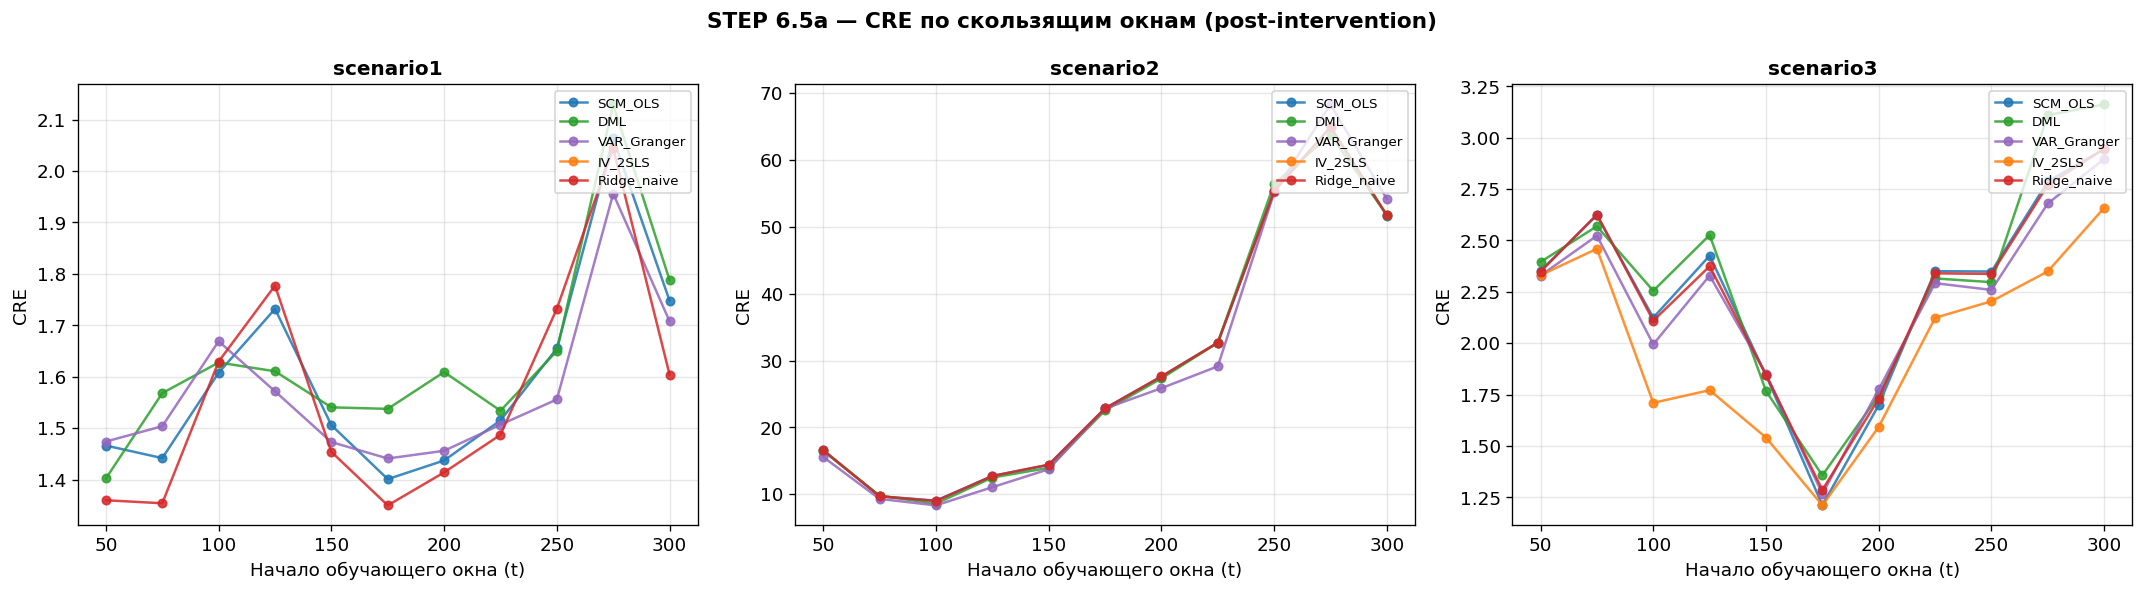

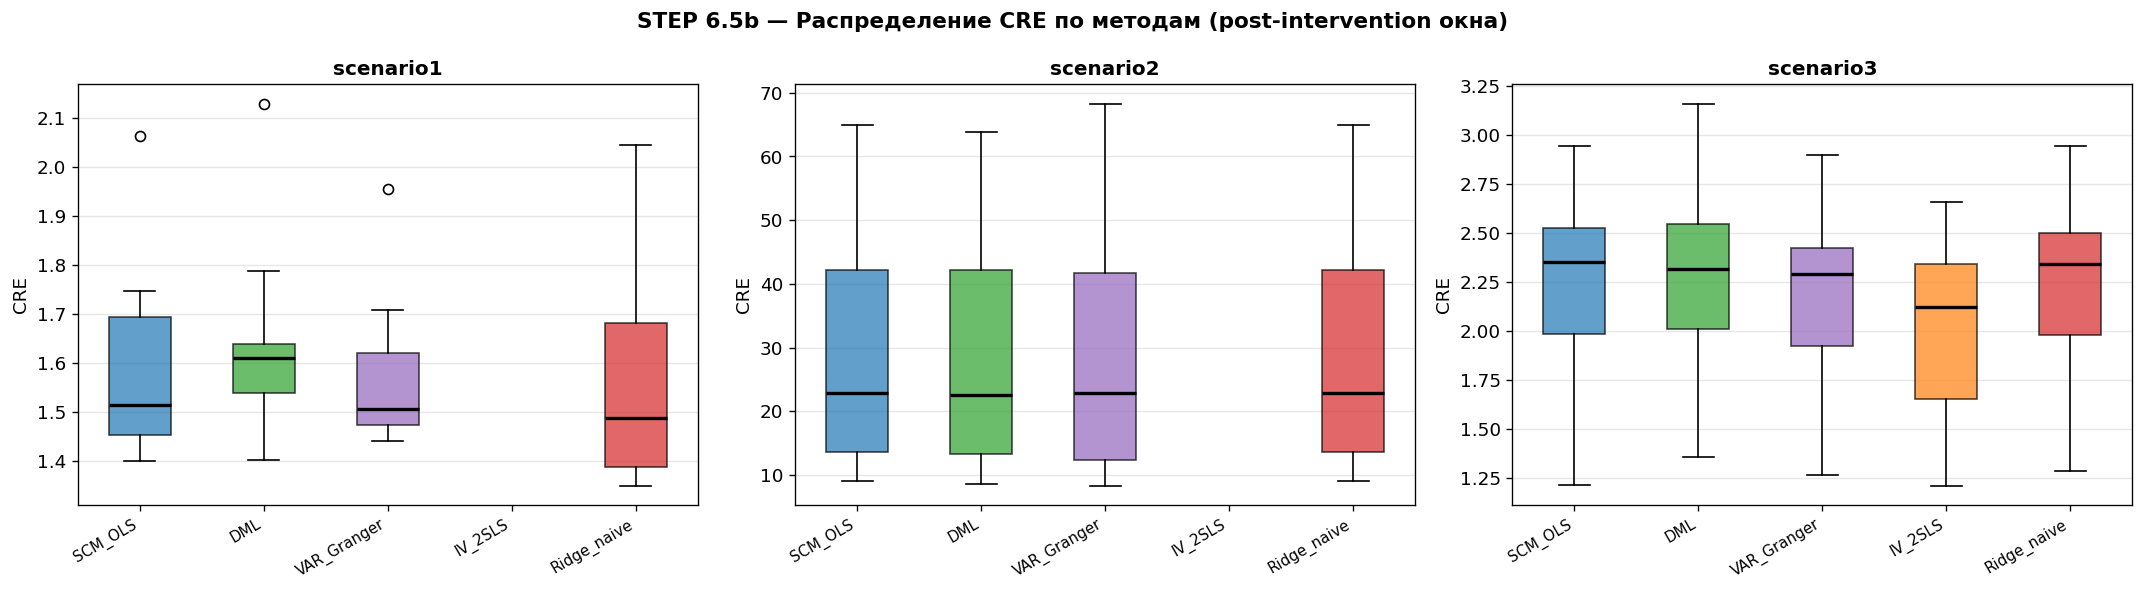

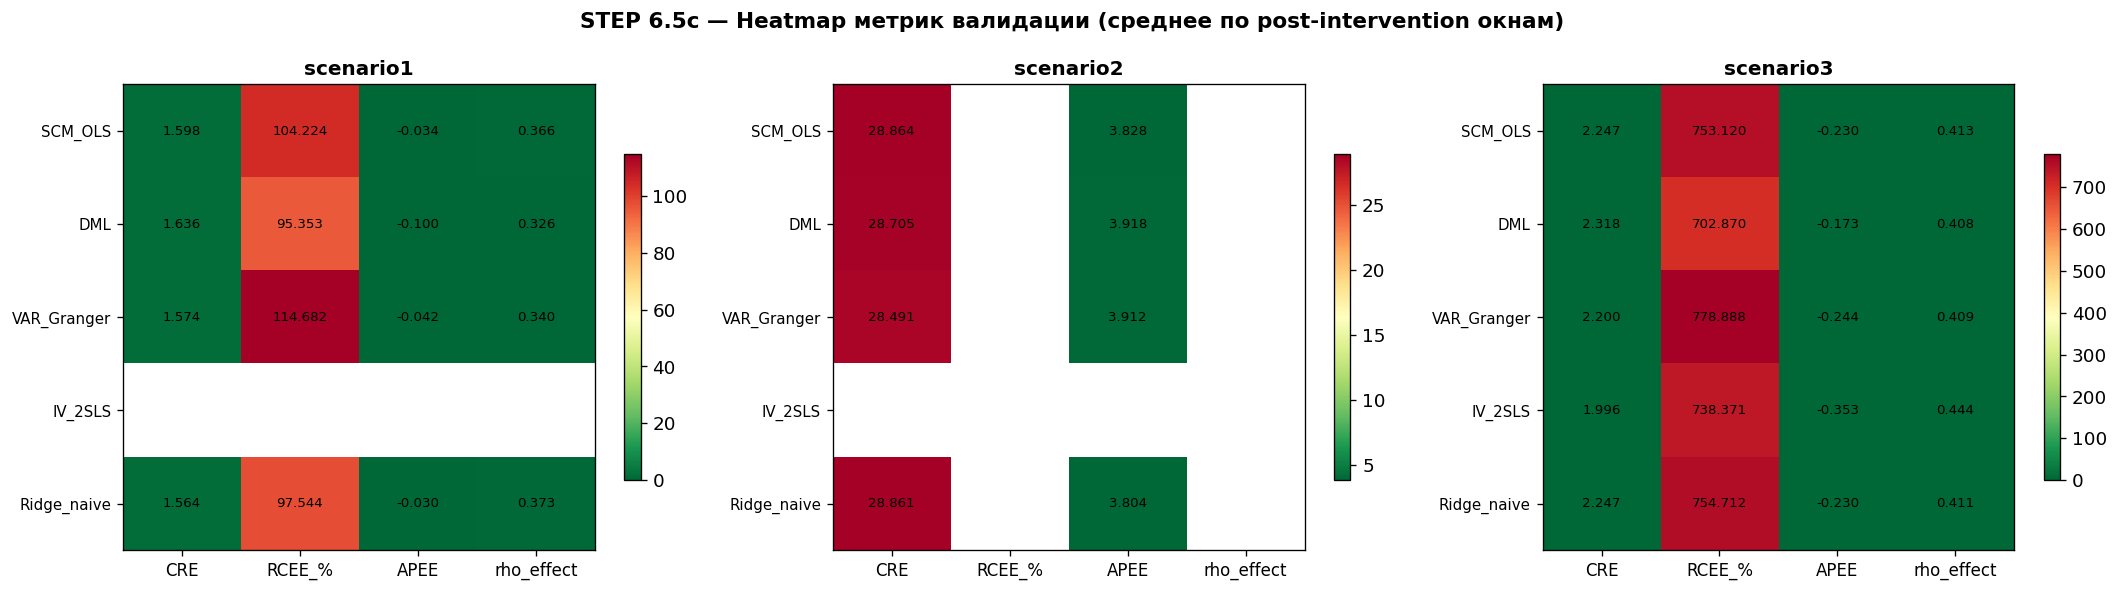

Визуализация валидации завершена.


In [29]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.5 — Визуализация результатов валидации
# ════════════════════════════════════════════════════════════════════════════

method_colors = {
    'SCM_OLS':     '#1f77b4',
    'DML':         '#2ca02c',
    'VAR_Granger': '#9467bd',
    'IV_2SLS':     '#ff7f0e',
    'Ridge_naive': '#d62728',
}

# ── График 1: CRE по окнам (динамика устойчивости) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle('STEP 6.5a — CRE по скользящим окнам (post-intervention)',
             fontsize=13, fontweight='bold')

for ax, (scenario, rw_df) in zip(axes, rw_results.items()):
    post_df = rw_df[rw_df['post_intervention']]
    for method, color in method_colors.items():
        sub = post_df[post_df['method'] == method].sort_values('window_start')
        if sub.empty: continue
        ax.plot(sub['window_start'], sub['CRE'], 'o-', color=color,
                lw=1.5, ms=5, label=method, alpha=0.85)
    ax.set_title(scenario, fontweight='bold')
    ax.set_xlabel('Начало обучающего окна (t)')
    ax.set_ylabel('CRE')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ── График 2: BoxPlot CRE по методам ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('STEP 6.5b — Распределение CRE по методам (post-intervention окна)',
             fontsize=13, fontweight='bold')

for ax, (scenario, rw_df) in zip(axes, rw_results.items()):
    post_df = rw_df[rw_df['post_intervention']]
    methods = list(method_colors.keys())
    data_bp = [post_df[post_df['method'] == m]['CRE'].dropna().values for m in methods]
    bp = ax.boxplot(data_bp, patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, m in zip(bp['boxes'], methods):
        patch.set_facecolor(method_colors[m])
        patch.set_alpha(0.7)
    ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
    ax.set_title(scenario, fontweight='bold')
    ax.set_ylabel('CRE'); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# ── График 3: Heatmap всех метрик (mean по окнам) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('STEP 6.5c — Heatmap метрик валидации (среднее по post-intervention окнам)',
             fontsize=13, fontweight='bold')

metrics_show = ['CRE', 'RCEE_%', 'APEE', 'rho_effect']

for ax, scenario in zip(axes, rw_results):
    methods = list(method_colors.keys())
    matrix  = []
    for m in methods:
        sub = agg_df[(agg_df['scenario'] == scenario) & (agg_df['method'] == m)]
        row_vals = []
        for met in metrics_show:
            v = sub[sub['metric'] == met]['mean'].values
            row_vals.append(float(v[0]) if len(v) > 0 else np.nan)
        matrix.append(row_vals)
    matrix = np.array(matrix, dtype=float)

    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r')
    ax.set_xticks(range(len(metrics_show))); ax.set_xticklabels(metrics_show, fontsize=10)
    ax.set_yticks(range(len(methods)));      ax.set_yticklabels(methods, fontsize=9)
    ax.set_title(scenario, fontweight='bold')
    for r in range(len(methods)):
        for c in range(len(metrics_show)):
            val = matrix[r, c]
            if not np.isnan(val):
                ax.text(c, r, f'{val:.3f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout(); plt.show()
print('Визуализация валидации завершена.')


In [30]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.6 — Сохранение результатов валидации
# ════════════════════════════════════════════════════════════════════════════

# Полные результаты по окнам
all_rw = pd.concat(
    [df.assign(scenario=scen) for scen, df in rw_results.items()],
    ignore_index=True
)

# Экспорт в Excel: лист 1 — агрегаты, лист 2 — детальные окна
with pd.ExcelWriter('validation_rolling_window.xlsx', engine='openpyxl') as writer:
    agg_df.to_excel(writer, sheet_name='Aggregated_Metrics', index=False)
    all_rw.to_excel(writer, sheet_name='Window_Details', index=False)
    # Сводная таблица CRE
    (agg_df[agg_df['metric'] == 'CRE']
     .pivot_table(index='method', columns='scenario', values='mean')
     .round(5)
     .to_excel(writer, sheet_name='CRE_Summary'))

print('Результаты сохранены в validation_rolling_window.xlsx')
print()
print('Итоговая сводка — CRE_mean по методам и сценариям:')
print(agg_df[agg_df['metric'] == 'CRE']
      .pivot_table(index='method', columns='scenario', values='mean')
      .round(5)
      .to_string())


PermissionError: [Errno 13] Permission denied: 'validation_rolling_window.xlsx'

In [31]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.3-ext — Rolling Window: расширенный набор методов
#
# Добавлены к исходным 5 методам:
#   6. ARIMA         (step4: rolling 1-step-ahead / DIRECT h>1)
#   7. RandomForest  (step4: n_estimators=300, без backdoor)
#   8. LSTM          (step4: PyTorch → Keras fallback)
#   9. CausalImpact  (step3: run_scm_dowhy — backdoor SCM прогноз)
#  10. DML_S3        (step3: EconML LinearDML → ручной DML, n_lags=5)
#
# Параметр use_extended=True/False позволяет включать/отключать
# расширенный набор (LSTM долго обучается — ≈3-5 мин на окно).
# ════════════════════════════════════════════════════════════════════════════

USE_EXTENDED_METHODS = True   # False — только оригинальные 5 методов
LSTM_EPOCHS          = 15     # уменьшено для rolling window (иначе слишком долго)
LSTM_SEQ_LEN         = 20


def rolling_window_validation_extended(
    df: pd.DataFrame,
    Y_cf_series: pd.Series,
    dag,
    expert_controls: List[str],
    t0: int      = T0,
    w_train: int = W_TRAIN,
    w_test: int  = W_TEST,
    step: int    = STEP_SIZE,
    use_extended: bool = True,
) -> pd.DataFrame:
    """
    Расширенная процедура скользящего окна.
    Запускает 10 методов (5 оригинальных + 5 из модулей step3/step4).

    Для каждого окна:
      - train: [i, i+w_train), test: [i+w_train, i+w_train+w_test)
      - Метрики CRE/RCEE/APEE/ρ — только для окон полностью после t0
    """
    T       = len(df)
    target  = dag.target
    causes  = dag.causes
    instrs  = dag.instruments
    ctrl_iv = [c for c in expert_controls if c not in instrs]
    all_feats = [c for c in df.columns if c != target]

    Y_obs_all = df[target].values
    Y_cf_all  = Y_cf_series.values

    rows = []

    for i in range(0, T - w_train - w_test + 1, step):
        train_end  = i + w_train
        test_start = train_end
        test_end   = train_end + w_test
        if test_end > T:
            break

        post_intervention = test_start >= t0

        # Датафреймы с RangeIndex (для оригинальных методов)
        df_train = df.iloc[i:train_end].reset_index(drop=True)
        df_test  = df.iloc[test_start:test_end].reset_index(drop=True)

        # Истинные значения на тесте
        Y_obs_test = Y_obs_all[test_start:test_end]
        Y_cf_test  = Y_cf_all[test_start:test_end]

        # ── Оригинальные 5 методов (из ноутбука) ─────────────────────────────
        original_methods = {
            'SCM_OLS':     lambda: run_scm_ols(df_train, target, expert_controls, causes),
            'DML':         lambda: run_dml(df_train, target, expert_controls, causes),
            'VAR_Granger': lambda: run_var_granger(df_train, target, expert_controls, causes),
            'IV_2SLS':     lambda: run_iv_2sls(df_train, target, ctrl_iv, causes, instrs),
            'Ridge_naive': lambda: run_ridge_naive(df_train, target, causes),
        }

        # ── Расширенные методы (из step3/step4 через адаптеры) ───────────────
        # Объединяем train + test для адаптеров (они сами делают train/test split
        # по TRAIN_RATIO = 0.8; для окна w_train=250, w_test=50 это ~83/17%)
        df_full_window = df.iloc[i:test_end].reset_index(drop=True)

        extended_methods = {}
        if use_extended:
            extended_methods = {
                'ARIMA': lambda: run_arima_adapter(
                    df_full_window, target, w_test, horizon=1),

                'RandomForest': lambda: run_rf_adapter(
                    df_full_window, target, all_feats, w_test, horizon=1),

                'LSTM': lambda: run_lstm_adapter(
                    df_full_window, target, all_feats, w_test,
                    horizon=1, epochs=LSTM_EPOCHS, seq_len=LSTM_SEQ_LEN),

                'CausalImpact': lambda: run_causal_impact_adapter(
                    df_full_window, target, causes, expert_controls,
                    dag, w_test, horizon=1),

                'DML_S3': lambda: run_dml_s3_adapter(
                    df_full_window, target, causes, expert_controls,
                    w_test, horizon=1),
            }

        all_methods = {**original_methods, **extended_methods}

        for m_name, m_func in all_methods.items():
            try:
                res = m_func()
            except Exception as e:
                res = {'method': m_name, 'preds': None, 'metrics': {}}

            # Унифицируем извлечение preds
            if m_name in original_methods:
                # оригинальные методы возвращают ключ 'preds' = numpy array
                raw = res.get('preds', None)
                if raw is not None:
                    arr = np.array(raw).flatten()[:w_test]
                    Y_cf_hat = np.concatenate(
                        [arr, np.full(max(0, w_test - len(arr)), np.nan)])
                else:
                    Y_cf_hat = np.full(w_test, np.nan)
            else:
                # адаптеры уже возвращают 'preds' длиной w_test
                Y_cf_hat = res.get('preds', np.full(w_test, np.nan))

            row = {
                'window_start':      i,
                'train_start':       i,
                'train_end':         train_end - 1,
                'test_start':        test_start,
                'test_end':          test_end - 1,
                'post_intervention': post_intervention,
                'method':            m_name,
                'method_label':      res.get('method', m_name),
                'theta_hat':         res.get('theta_hat', np.nan),
                'RMSE_pred':         res.get('metrics', {}).get('RMSE', np.nan),
            }

            if post_intervention:
                vm = all_validation_metrics(
                    Y_obs_test, Y_cf_test, Y_cf_hat,
                    label=f'w{i}_{m_name}'
                )
                row.update({'CRE': vm['CRE'], 'RCEE_%': vm['RCEE_%'],
                            'APEE': vm['APEE'], 'rho_effect': vm['rho_effect']})
            else:
                row.update({'CRE': np.nan, 'RCEE_%': np.nan,
                            'APEE': np.nan, 'rho_effect': np.nan})

            rows.append(row)

    return pd.DataFrame(rows)


# ── Запуск расширенного Rolling Window ─────────────────────────────────────
print('Запуск расширенного Rolling Window (10 методов)...')
print(f'  LSTM: epochs={LSTM_EPOCHS}, seq_len={LSTM_SEQ_LEN}')
print(f'  Ожидаемое время: ~5–20 мин в зависимости от наличия PyTorch/CUDA')
print()

rw_results_ext = {}

for scenario, cfd in cf_data.items():
    info   = var_selection[scenario]
    expert = info['expert']
    df_raw = cfd['df']
    Y_cf_s = cfd['Y_cf']
    dag    = cfd['dag']

    print(f'  {scenario}...', end=' ', flush=True)
    rw_df_ext = rolling_window_validation_extended(
        df_raw, Y_cf_s, dag, expert,
        t0=T0, w_train=W_TRAIN, w_test=W_TEST, step=STEP_SIZE,
        use_extended=USE_EXTENDED_METHODS,
    )
    rw_results_ext[scenario] = rw_df_ext
    n_meth = rw_df_ext['method'].nunique()
    n_post = rw_df_ext[rw_df_ext['post_intervention']]['window_start'].nunique()
    print(f'методов={n_meth}, post-intervention окон={n_post} ✓')

print('\nRolling Window (расширенный) завершён.')


Запуск расширенного Rolling Window (10 методов)...
  LSTM: epochs=15, seq_len=20
  Ожидаемое время: ~5–20 мин в зависимости от наличия PyTorch/CUDA

  scenario1... 

21:27:01 │ INFO    │   [ARIMA] Y  h=1
21:27:06 │ INFO    │     ARIMA_direct(h=1): RMSE=1.5449  MAE=1.2863  MAPE=172.90%  R²=0.0851
21:27:06 │ INFO    │   [RandomForest] Y
21:27:06 │ INFO    │     RandomForest: RMSE=1.3040  MAE=1.0359  MAPE=162.98%  R²=0.3559
21:27:06 │ INFO    │   [LSTM] Y
21:27:26 │ INFO    │     epoch 10/15 loss=0.2065
21:27:26 │ INFO    │     LSTM_PyTorch: RMSE=1.5779  MAE=1.2816  MAPE=107.62%  R²=0.0455
21:27:26 │ INFO    │   [SCM-DoWhy] Y  h=1
21:27:28 │ ERROR   │ Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
21:27:28 │ ERROR   │ Error: Pydot cannot be loaded. Graph.get_strict() takes 1 positional argument but 2 were given
21:27:28 │ WARNING │     DoWhy ошибка: Graph.get_strict() takes 1 positional argument but 2 were given
21:27:28 │ INFO    │     Ridge alpha=10.000
21:27:28 │ INFO    │     GBM n_features=7
21:27:28 │ INFO    │     SCM_Ridge+GBM(h=1): RMSE=1.5340  MAE=1.2208  MAPE=139.81%  R²=0.0979
21:27:28 │ INFO    │   [DML]

методов=10, post-intervention окон=11 ✓
  scenario2... 

21:28:18 │ INFO    │   [ARIMA] Y  h=1
21:28:20 │ INFO    │     ARIMA_direct(h=1): RMSE=16.1425  MAE=10.7211  MAPE=115.61%  R²=0.0689
21:28:20 │ INFO    │   [RandomForest] Y
21:28:20 │ INFO    │     RandomForest: RMSE=13.6850  MAE=7.9998  MAPE=67.02%  R²=0.3264
21:28:20 │ INFO    │   [LSTM] Y
21:28:21 │ INFO    │     epoch 10/15 loss=0.0235
21:28:21 │ INFO    │     LSTM_PyTorch: RMSE=16.2951  MAE=11.2240  MAPE=103.71%  R²=0.0513
21:28:21 │ INFO    │   [SCM-DoWhy] Y  h=1
21:28:21 │ ERROR   │ Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
21:28:21 │ ERROR   │ Error: Pydot cannot be loaded. Graph.get_strict() takes 1 positional argument but 2 were given
21:28:21 │ WARNING │     DoWhy ошибка: Graph.get_strict() takes 1 positional argument but 2 were given
21:28:21 │ INFO    │     Ridge alpha=10.000
21:28:22 │ INFO    │     GBM n_features=7
21:28:22 │ INFO    │     SCM_Ridge+GBM(h=1): RMSE=15.2990  MAE=10.3622  MAPE=113.10%  R²=0.1637
21:28:22 │ INFO    │  

методов=10, post-intervention окон=11 ✓
  scenario3... 

21:29:42 │ INFO    │   [ARIMA] Y  h=1
21:29:44 │ INFO    │     ARIMA_direct(h=1): RMSE=1.5908  MAE=1.2315  MAPE=210.56%  R²=0.4389
21:29:44 │ INFO    │   [RandomForest] Y
21:29:44 │ INFO    │     RandomForest: RMSE=1.3825  MAE=1.1221  MAPE=167.89%  R²=0.5864
21:29:44 │ INFO    │   [LSTM] Y
21:29:45 │ INFO    │     epoch 10/15 loss=0.1277
21:29:45 │ INFO    │     LSTM_PyTorch: RMSE=1.7562  MAE=1.3522  MAPE=127.23%  R²=0.3162
21:29:45 │ INFO    │   [SCM-DoWhy] Y  h=1
21:29:45 │ ERROR   │ Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...
21:29:45 │ ERROR   │ Error: Pydot cannot be loaded. Graph.get_strict() takes 1 positional argument but 2 were given
21:29:45 │ WARNING │     DoWhy ошибка: Graph.get_strict() takes 1 positional argument but 2 were given
21:29:45 │ INFO    │     Ridge alpha=1.000
21:29:45 │ INFO    │     GBM n_features=7
21:29:45 │ INFO    │     SCM_Ridge+GBM(h=1): RMSE=1.3717  MAE=1.1255  MAPE=185.15%  R²=0.5828
21:29:45 │ INFO    │   [DML] 

методов=10, post-intervention окон=11 ✓

Rolling Window (расширенный) завершён.


scenario      scenario1  scenario2  scenario3
method                                       
ARIMA           1.35683   28.09680    1.84109
CausalImpact    1.43424   27.26472    1.93095
DML             1.63623   28.70505    2.31835
IV_2SLS             NaN        NaN    1.99579
LSTM            1.31579   23.56024    1.61757
RandomForest    1.45063   25.68302    2.00618
Ridge_naive     1.56437   28.86139    2.24675
SCM_OLS         1.59769   28.86357    2.24650
VAR_Granger     1.57424   28.49080    2.19983


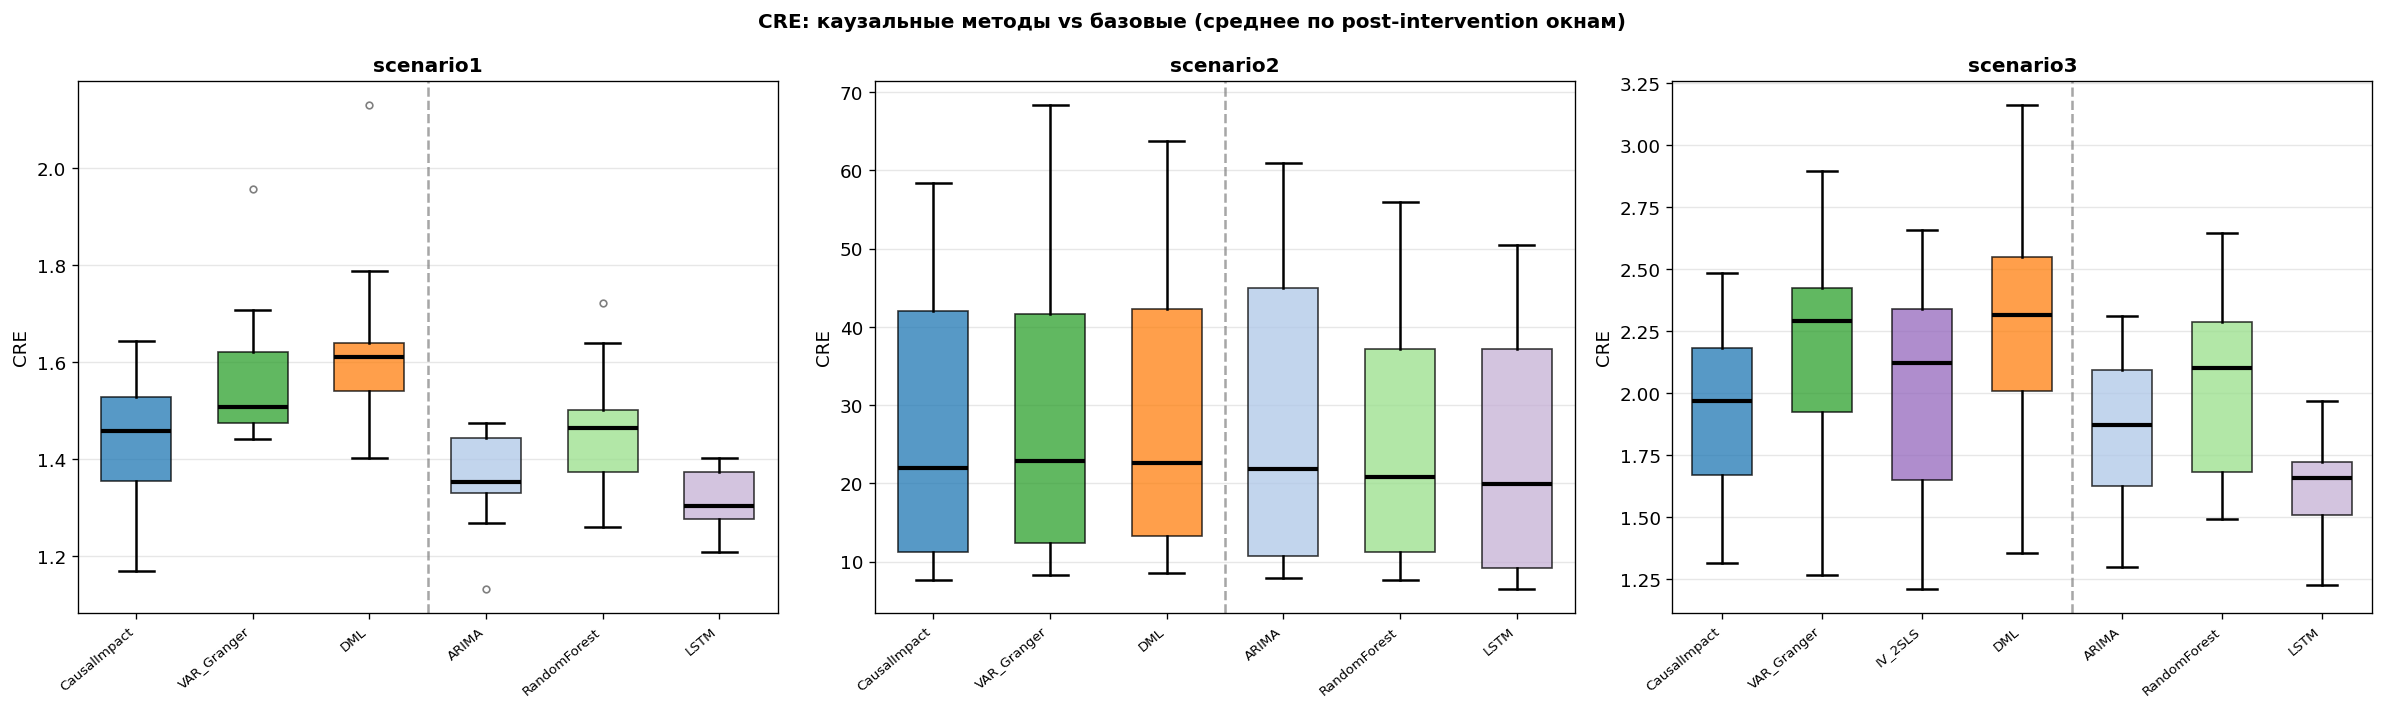

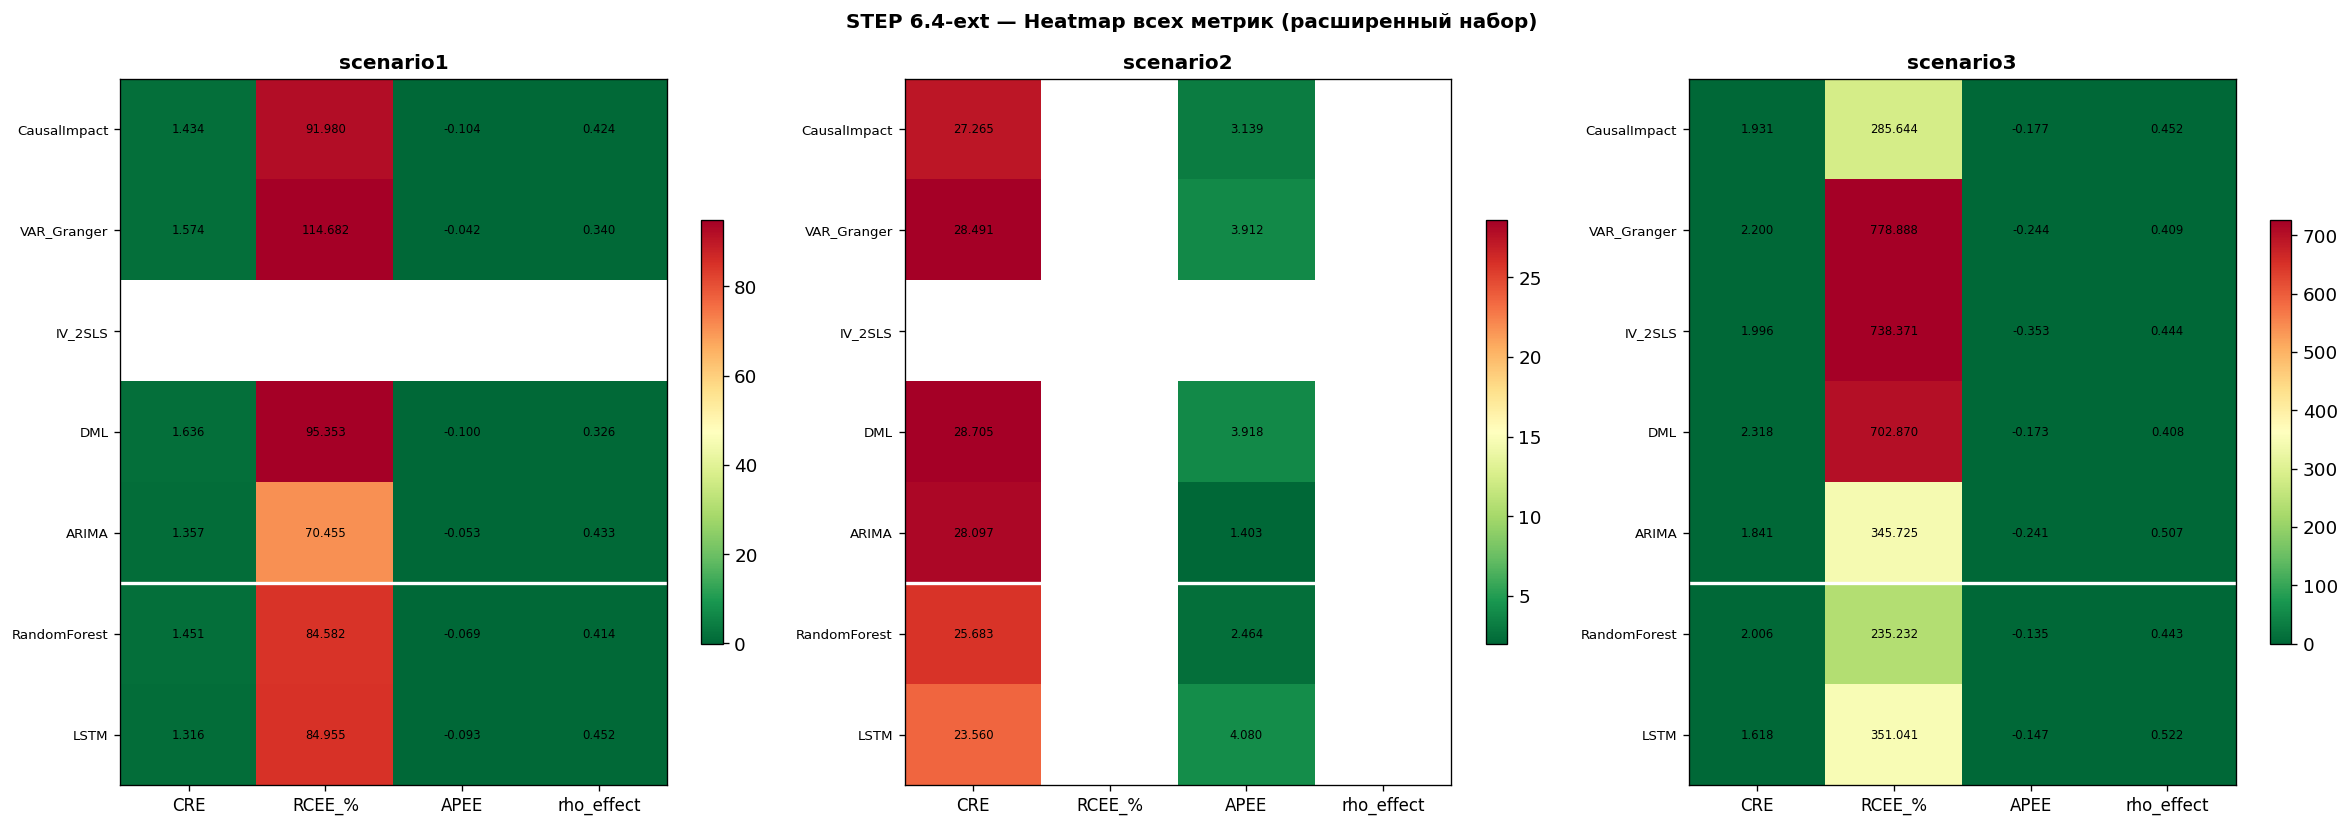

In [43]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.4-ext — Агрегация и визуализация расширенного Rolling Window
# ════════════════════════════════════════════════════════════════════════════

agg_rows_ext = []

for scenario, rw_df in rw_results_ext.items():
    post_df = rw_df[rw_df['post_intervention']].copy()
    for method in post_df['method'].unique():
        sub = post_df[post_df['method'] == method]
        for metric in ['CRE', 'RCEE_%', 'APEE', 'rho_effect']:
            vals = sub[metric].dropna()
            if len(vals) == 0:
                continue
            m, s, n = float(vals.mean()), float(vals.std()), len(vals)
            ci_h = 1.96 * s / np.sqrt(n) if n > 1 else np.nan
            agg_rows_ext.append({
                'scenario': scenario, 'method': method, 'metric': metric,
                'N_windows': n,
                'mean':     round(m, 5),
                'std':      round(s, 5),
                'CI_lower': round(m - ci_h, 5) if not np.isnan(ci_h) else np.nan,
                'CI_upper': round(m + ci_h, 5) if not np.isnan(ci_h) else np.nan,
            })

agg_df_ext = pd.DataFrame(agg_rows_ext)

# ── Сводная таблица CRE (все методы) ───────────────────────────────────────
cre_pivot = (agg_df_ext[agg_df_ext['metric'] == 'CRE']
             .pivot_table(index='method', columns='scenario', values='mean')
             .round(5))
print(cre_pivot.to_string())


# ── Визуализация 1: CRE grouped barplot (оригинальные vs step3/step4) ───────
method_groups = {
    'Причинно-следственные методы': ['CausalImpact', 'VAR_Granger', 'IV_2SLS', 'DML'],
    'Базовые методы': ['ARIMA', 'RandomForest', 'LSTM'],
}
all_methods_ordered = (
    method_groups['Причинно-следственные методы'] +
    method_groups['Базовые методы']
)

palette_orig = ['#1f77b4','#2ca02c','#9467bd','#ff7f0e']
palette_ext  = ['#aec7e8','#98df8a','#c5b0d5']
method_color_map = dict(zip(all_methods_ordered, palette_orig + palette_ext))


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('CRE: каузальные методы vs базовые (среднее по post-intervention окнам)',
             fontsize=12, fontweight='bold')

for ax, (scenario, rw_df) in zip(axes, rw_results_ext.items()):
    post_df = rw_df[rw_df['post_intervention']]
    data_bp, labels, colors_bp = [], [], []
    for m in all_methods_ordered:
        vals = post_df[post_df['method'] == m]['CRE'].dropna().values
        if len(vals) > 0:
            data_bp.append(vals)
            labels.append(m)
            colors_bp.append(method_color_map[m])

    bp = ax.boxplot(
        data_bp, patch_artist=True,
        medianprops=dict(color='black', lw=2.5),
        whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
        widths=0.6,
    )
    for patch, col in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)

    n_orig = len([m for m in method_groups['Причинно-следственные методы'] if m in labels])
    if n_orig < len(labels):
        ax.axvline(n_orig + 0.5, color='gray', lw=1.5, ls='--', alpha=0.7)

    #ax.axhline(0, color='red', lw=1, ls=':', alpha=0.6)   # нулевая корреляция
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    ax.set_title(scenario, fontweight='bold')
    ax.set_ylabel('CRE')
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── Визуализация 2: Heatmap всех метрик × все методы ───────────────────────
metrics_show = ['CRE', 'RCEE_%', 'APEE', 'rho_effect']


fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('STEP 6.4-ext — Heatmap всех метрик (расширенный набор)',
             fontsize=12, fontweight='bold')

for ax, scenario in zip(axes, rw_results_ext):
    matrix = []
    for m in all_methods_ordered:
        row_vals = []
        for met in metrics_show:
            v = agg_df_ext[(agg_df_ext['scenario'] == scenario) &
                           (agg_df_ext['method'] == m) &
                           (agg_df_ext['metric'] == met)]['mean'].values
            row_vals.append(float(v[0]) if len(v) > 0 else np.nan)
        matrix.append(row_vals)
    matrix = np.array(matrix, dtype=float)

    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r',
                   vmin=np.nanpercentile(matrix, 5),
                   vmax=np.nanpercentile(matrix, 95))
    ax.set_xticks(range(len(metrics_show)))
    ax.set_xticklabels(metrics_show, fontsize=10)
    ax.set_yticks(range(len(all_methods_ordered)))
    ax.set_yticklabels(all_methods_ordered, fontsize=8)
    ax.set_title(scenario, fontweight='bold')
    # Горизонтальная разделительная линия между группами
    ax.axhline(4.5, color='white', lw=2)
    for r in range(len(all_methods_ordered)):
        for c in range(len(metrics_show)):
            if not np.isnan(matrix[r, c]):
                ax.text(c, r, f'{matrix[r,c]:.3f}',
                        ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.6)

plt.tight_layout(); plt.show()


In [36]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 6.5-ext — Экспорт расширенных результатов валидации
# ════════════════════════════════════════════════════════════════════════════

all_rw_ext = pd.concat(
    [df.assign(scenario=scen) for scen, df in rw_results_ext.items()],
    ignore_index=True
)

with pd.ExcelWriter('validation_rolling_window_extended.xlsx',
                    engine='openpyxl') as writer:
    agg_df_ext.to_excel(writer, sheet_name='Aggregated_Metrics',  index=False)
    all_rw_ext.to_excel(writer, sheet_name='Window_Details',       index=False)

    # CRE сводная таблица
    (agg_df_ext[agg_df_ext['metric'] == 'CRE']
     .pivot_table(index='method', columns='scenario', values='mean')
     .round(5)
     .to_excel(writer, sheet_name='CRE_Summary'))

    # Полная сводная (все метрики)
    (agg_df_ext
     .pivot_table(index=['method', 'metric'], columns='scenario', values='mean')
     .round(5)
     .to_excel(writer, sheet_name='All_Metrics_Summary'))

print('Результаты сохранены → validation_rolling_window_extended.xlsx')
print()
print('Итоговая сводка CRE (все 10 методов):')
print(agg_df_ext[agg_df_ext['metric'] == 'CRE']
      .pivot_table(index='method', columns='scenario', values='mean')
      .round(5)
      .to_string())


Результаты сохранены → validation_rolling_window_extended.xlsx

Итоговая сводка CRE (все 10 методов):
scenario      scenario1  scenario2  scenario3
method                                       
ARIMA           1.35683   28.09680    1.84109
CausalImpact    1.43424   27.26472    1.93095
DML             1.63623   28.70505    2.31835
IV_2SLS             NaN        NaN    1.99579
LSTM            1.31579   23.56024    1.61757
RandomForest    1.45063   25.68302    2.00618
Ridge_naive     1.56437   28.86139    2.24675
SCM_OLS         1.59769   28.86357    2.24650
VAR_Granger     1.57424   28.49080    2.19983
